# **A Multifactor Perspective on Volatility-Managed Portfolios**
**DeMigue、Martín-Utrera, Uppal（2024）** ***The journal of Finance***

### **研究问题**
- 背景：Moreira & Muir (2017) 提出通过在高波动期缩减风险因子暴露可以提升 Sharpe 比率，从而挑战传统的“风险—收益”正向关系。后续工作（Cederburg 等、Barroso & Detzel）指出：估计误差与交易成本会抹去这些收益。

- 研究问题：
1. VMP在多因子层面是否依然有效？
2. 如果有效，其来源是什么？风险溢价？交易结构？成本或优化方式？

### **方法论**

- **因子与样本**：使用与 Moreira & Muir 相同的 9 个因子（MKT, SMB, HML, RMW, CMA, UMD, ROE, IA, BAB）， 1967–2020（评估的样本外段为 1977–2020）。
- **条件化权重参数化**：对第 k 因子的权重设为仿射形式 $\theta_{k,t} = a_k + {b_k/\sigma_t}$，其中 $\sigma_t$是当月实证市场波动率。
    - 正的 $b_k$意味着在高波动时减少该因子暴露。
- **优化目标**：构造“扩展”因子向量，把 $a_k$与 $b_k$ 统一进一个扩展权重向量 η；
    - 通过解决一个带交易成本的 mean-variance 最优化问题（并加上 η≥0 的约束）来估计最优条件化多因子组合。
- **交易成本处理**：在股票层面估计逐月交易成本（用 Abdi & Ranaldo 的两日修正方法估计买卖价差），
    - 并且显式考虑交易净额跨因子的对冲（trading diversification），即先在股票层面 net 掉不同因子组合的交易再计成本。

### **主要发现**

**个别因子层面**：复现并拓展既有发现——单独对某些因子做波动率管理在样本内可能看起来好，但在样本外或计入交易成本后多数并不显著提升表现（与 Cederburg、Barroso & Detzel 的结论一致）。

**多因子层面**：提出的条件化均值—方差多因子组合（CMV）在样本外且扣除交易成本后仍显著优于非条件化多因子组合（UMV）：CMV 年化 Sharpe≈1.062，UMV≈0.940（CMV 比 UMV 高约 13%，差异在统计上显著）。该超额表现还能体现为正的时间序列 alpha（t-stat > 3）。

### **驱动因素**：

**交易多样化**（trading diversification）：把多个因子合并后，因子间的交易方向可相互抵消，显著降低总交易成本；
对 CMV 带来的净效应尤其大，因为被管理（managed）的因子本身交易成本高。

**在优化中显式考虑交易成本**：直接把成本纳入最优化能改变权重配置，显著提升 CMV 的净表现。

**允许因子权重随波动差异化变化**：有些因子应强烈时序化，有些则保持稳定；这种差别化使 CMV 在平均暴露上与 UMV 有显著差异（例如对 HML、UMD、BAB 权重上升，对 IA、CMA 下降），进而改善风险调整后收益。

In [1]:
import numpy as np
import pandas as pd
import cvxpy as cp
import os
from datetime import datetime
import time
from scipy.optimize import minimize
from scipy.stats import norm
from scipy.linalg import inv
from typing import Tuple, Dict, List
import h5py
import scipy.io
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 中文黑体
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号
import warnings
warnings.filterwarnings('ignore')

### **数据处理**

In [112]:
# 使用h5py读取MAT文件
f = h5py.File('E:/zhaoweihao/DeMiguel 2024/ReplicationPackage/Data/MainDataRep.mat', 'r')

# 提取主要变量
RPS = np.array(f['RPS']).T  # 转置以匹配Matlab维度顺序
RPSext = np.array(f['RPSext']).T
Rchar = np.array(f['Rchar']).T
# 其他变量按需提取...
print(f"原始数据维度: RPS {RPS.shape}, RPSext {RPSext.shape}")

# 处理第9个因子 (Matlab索引从1开始，Python从0开始，所以是索引8)
BAB = np.squeeze(RPS[:, 8, :]) 
BAB[BAB == 0] = np.nan          
RPS[:, 8, :] = BAB              
RPSext[:, 8, :] = BAB           
# 处理第18个因子 (Python索引17)
BAB = np.squeeze(RPSext[:, 17, :])  
BAB[BAB == 0] = np.nan              
RPSext[:, 17, :] = BAB              
print(f"处理后数据维度: RPS {RPS.shape}, RPSext {RPSext.shape}")

原始数据维度: RPS (647, 9, 24991), RPSext (647, 18, 24991)
处理后数据维度: RPS (647, 9, 24991), RPSext (647, 18, 24991)


In [113]:
# 提取其他需要的变量
BidAskSpreads = np.array(f['BidAskSpreads']).T
rRisky = np.array(f['rRisky']).T
RcharD = np.array(f['RcharD']).T
Dates = np.array(f['Dates']).T
DatesBA = np.array(f['DatesBA']).T
DatesLag = np.array(f['DatesLag']).T
DatesFFd = np.array(f['DatesFFd']).T
Rcharext = np.array(f['Rcharext']).T
VIXmonth = np.array(f['VIXmonth']).T

f.close()  # 关闭文件

In [114]:
print(BidAskSpreads.shape)
print(rRisky.shape)
print(RcharD.shape)
print(Dates.shape)
print(DatesBA.shape)
print(DatesLag.shape)
print(DatesFFd.shape)
print(Rcharext.shape)
print(VIXmonth.shape)

(647, 24991)
(647, 24991)
(24896, 9)
(647, 1)
(648, 1)
(647, 1)
(24896, 1)
(647, 18)
(647, 1)


In [5]:
print(f"RcharD: {RcharD.shape}")
print(f"DatesFFd: {DatesFFd.shape}")
    
print(f"\nDatesFFd: {type(DatesFFd)}")
print(f"DatesFFd前5个值: {DatesFFd[:5] if len(DatesFFd) > 5 else DatesFFd}")

RcharD: (24896, 9)
DatesFFd: (24896, 1)

DatesFFd: <class 'numpy.ndarray'>
DatesFFd前5个值: [[19260701.]
 [19260702.]
 [19260706.]
 [19260707.]
 [19260708.]]


In [6]:
def load_main_data(mat_file_path):
    f = h5py.File(mat_file_path, 'r')
    # 提取主要变量并转置以匹配Matlab维度顺序
    data_dict = {
        'RPS': np.array(f['RPS']).T,
        'RPSext': np.array(f['RPSext']).T,
        'Rchar': np.array(f['Rchar']).T,
        'BidAskSpreads': np.array(f['BidAskSpreads']).T,
        'rRisky': np.array(f['rRisky']).T,
        'RcharD': np.array(f['RcharD']).T,
        'Dates': np.array(f['Dates']).T,
        'DatesBA': np.array(f['DatesBA']).T,
        'DatesLag': np.array(f['DatesLag']).T,
        'DatesFFd': np.array(f['DatesFFd']).T,
        'Rcharext': np.array(f['Rcharext']).T,
        'VIXmonth': np.array(f['VIXmonth']).T}
    
    f.close()
    
    # 处理BAB因子数据
    BAB = np.squeeze(data_dict['RPS'][:, 8, :]) 
    BAB[BAB == 0] = np.nan          
    data_dict['RPS'][:, 8, :] = BAB              
    data_dict['RPSext'][:, 8, :] = BAB           
    BAB = np.squeeze(data_dict['RPSext'][:, 17, :])  
    BAB[BAB == 0] = np.nan              
    data_dict['RPSext'][:, 17, :] = BAB
    
    return data_dict

### **交易成本 = 买卖价差 × |权重变化量|**

其中权重变化量考虑了股票收益率的自然变化：

如果股票价格上涨，即使权重不变，以金额计算的仓位也会增加

因此需要从上期权重中扣除价格变动的影响

In [7]:
# 获取维度信息
K = RPS.shape[1]       # 因子数量 = 9
D = RPS.shape[0] - 1   # 时间长度减1
TCs = BidAskSpreads.T  # 现在维度: (24991, 647)

# 初始化交易成本矩阵
Phi = np.zeros((TCs.shape[0], K, D))  # (股票数, 因子数, 时间)
Phiext = np.zeros((TCs.shape[0], RPSext.shape[1], D))

# 计算每个时间点的交易成本
for j in range(D):
    # 当前交易成本
    current_TC = TCs[:, -D+j].reshape(-1, 1)  # 列向量   
    # 计算权重变化 (当前权重 - 上期调整后权重)
    weight_change = (np.squeeze(RPS[-D+j, :, :]).T - (np.squeeze(RPS[-D+j-1, :, :]).T * (1 + rRisky[-D+j-1, :]).reshape(-1, 1)))
    # 计算交易成本矩阵
    Phi[:, :, j] = current_TC * weight_change
    # 对扩展因子做同样计算
    weight_change_ext = (np.squeeze(RPSext[-D+j, :, :]).T - (np.squeeze(RPSext[-D+j-1, :, :]).T * (1 + rRisky[-D+j-1, :]).reshape(-1, 1)))
    Phiext[:, :, j] = current_TC * weight_change_ext

print("交易成本矩阵计算完成")

交易成本矩阵计算完成


In [8]:
Phi = np.nan_to_num(Phi)  # 将NaN替换为0
Phiext = np.nan_to_num(Phiext)
NN = Phi.shape[0]  # 股票数量

# 将维度从 (NN, K, D) 变为 (NN, D, K)
Phi_permuted = np.transpose(Phi, (0, 2, 1))  # (NN, D, K)
Phi2 = Phi_permuted.reshape(NN * D, K)

# 对扩展因子做同样操作
Phiext_permuted = np.transpose(Phiext, (0, 2, 1))  # (NN, D, RPSext.shape[1])
Phiext2 = Phiext_permuted.reshape(NN * D, RPSext.shape[1])
print(f"维度转换完成: Phi2 {Phi2.shape}, Phiext2 {Phiext2.shape}")

# 选择第二列不为0的行
nonzero_mask = Phi2[:, 1] != 0  # 第二列索引为1
Phi2 = Phi2[nonzero_mask, :]
Phi2 = np.nan_to_num(Phi2) # 再次清除可能的NaN值

# 对扩展因子做同样操作
nonzero_mask_ext = Phiext2[:, 1] != 0
Phiext2 = Phiext2[nonzero_mask_ext, :]
Phiext2 = np.nan_to_num(Phiext2)
print(f"过滤后维度: Phi2 {Phi2.shape}, Phiext2 {Phiext2.shape}")

# === 计算平均交易成本 ===
TC = np.sum(np.abs(Phi2), axis=0) / D
TCext = np.sum(np.abs(Phiext2), axis=0) / D
print(f"TC样本值: {TC[:5]}")  # 显示前5个值

维度转换完成: Phi2 (16144186, 9), Phiext2 (16144186, 18)
过滤后维度: Phi2 (2564171, 9), Phiext2 (2564171, 18)
TC样本值: [0.00014232 0.00070525 0.00097461 0.00095431 0.0013105 ]


#### **维度信息**：
- 原始数据：Phi2 (16144186, 9) - 约1600万行 × 9个因子
- 过滤后：Phi2 (2564171, 9) - 约250万行 × 9个因子
- 过滤掉了约84%的行，说明大部分权重变化为0

#### **与论文数据的对比**
根据论文图2，不同因子的交易成本大致在：
- MKT: ~1-2 bps (0.0001-0.0002)
- SMB: ~7.5 bps (0.00075)
- HML: ~10 bps (0.0010)
- UMD: ~46 bps (0.0046)

**TC样本值与这些参考值在同一个数量级，说明计算是正确的**。

#### **构建交易成本矩阵 -TCconstruction_PhiMatrix**
参数:  
    RPS: 股票权重矩阵 (时间×因子×股票)  
    RPSext: 扩展股票权重矩阵  
    BidAskSpreads: 买卖价差矩阵   
    rRisky: 股票收益率矩阵  
    
返回:    
    TC: 平均交易成本向量     
    Phi: 交易成本矩阵 (3D)    
    Phi2: 重组后的交易成本矩阵 (2D)   
    TCext: 扩展平均交易成本向量   
    Phiext: 扩展交易成本矩阵 (3D)  
    Phiext2: 重组后的扩展交易成本矩阵 (2D)  

In [9]:
def TCconstruction_PhiMatrix(RPS, RPSext, BidAskSpreads, rRisky):  
    K = RPS.shape[1]       # 因子数量 = 9
    D = RPS.shape[0] - 1   # 时间长度减1
    TCs = BidAskSpreads.T  # 现在维度: (24991, 647)
    # 初始化交易成本矩阵
    Phi = np.zeros((TCs.shape[0], K, D))  # (股票数, 因子数, 时间)
    Phiext = np.zeros((TCs.shape[0], RPSext.shape[1], D))
    # 计算每个时间点的交易成本
    for j in range(D):
        # 当前交易成本
        current_TC = TCs[:, -D+j].reshape(-1, 1)  # 列向量   
        # 计算权重变化 (当前权重 - 上期调整后权重)
        weight_change = (np.squeeze(RPS[-D+j, :, :]).T - (np.squeeze(RPS[-D+j-1, :, :]).T * (1 + rRisky[-D+j-1, :]).reshape(-1, 1)))
        # 计算交易成本矩阵
        Phi[:, :, j] = current_TC * weight_change
        # 对扩展因子做同样计算
        weight_change_ext = (np.squeeze(RPSext[-D+j, :, :]).T - (np.squeeze(RPSext[-D+j-1, :, :]).T * (1 + rRisky[-D+j-1, :]).reshape(-1, 1)))
        Phiext[:, :, j] = current_TC * weight_change_ext

    Phi = np.nan_to_num(Phi)
    Phiext = np.nan_to_num(Phiext)
    NN = Phi.shape[0]  # 股票数量
    # 将维度从 (NN, K, D) 变为 (NN, D, K)
    Phi_permuted = np.transpose(Phi, (0, 2, 1))  # (NN, D, K)
    Phi2 = Phi_permuted.reshape(NN * D, K)
    # 对扩展因子做同样操作
    Phiext_permuted = np.transpose(Phiext, (0, 2, 1))  # (NN, D, RPSext.shape[1])
    Phiext2 = Phiext_permuted.reshape(NN * D, RPSext.shape[1])
    # 第二列不为0的行
    nonzero_mask = Phi2[:, 1] != 0  
    Phi2 = Phi2[nonzero_mask, :]
    Phi2 = np.nan_to_num(Phi2)
    # 对扩展因子做同样操作
    nonzero_mask_ext = Phiext2[:, 1] != 0
    Phiext2 = Phiext2[nonzero_mask_ext, :]
    Phiext2 = np.nan_to_num(Phiext2)

    # 计算平均交易成本
    TC = np.sum(np.abs(Phi2), axis=0) / D
    TCext = np.sum(np.abs(Phiext2), axis=0) / D
    
    return TC, Phi, Phi2, TCext, Phiext, Phiext2

### **0. 初始化所有参数和结果数组**
- Rchar: 因子收益率矩阵 (T x K)
- Rcharext: 扩展因子收益率矩阵 (T x 扩展因子数)  
- M: 估计窗口长度 (默认120个月)
- ew: 参数重新估计频率 (默认12个月)
    
返回:所有初始化后的数组和参数

In [10]:
def initialize_parameters(Rchar, Rcharext, M=120, ew=12):
    # 获取数据维度
    T, K = Rchar.shape
    n_factors_ext = Rcharext.shape[1]  # 扩展因子数量
    # 初始化权重矩阵
    thetas = np.full((n_factors_ext, T-M, 6), np.nan) # (扩展因子数, 样本外期数, 6种策略）
    
    # 初始化收益结果矩阵
    PolicyReturns = np.full((T-M, 6), np.nan)           
    PolicyReturnsTC = np.full((T-M, 6), np.nan)         
    PolicyReturnsTCntd = np.full((T-M, 6), np.nan)   
    
    # 初始化波动率序列
    sigmaUMV = np.full(T-M, np.nan)     # 无条件组合波动率
    sigmaUMVtc = np.full(T-M, np.nan)   # 考虑交易成本的无条件组合波动率
    
    return {'thetas': thetas, 'T': T,  'K': K, 'n_factors_ext': n_factors_ext, 'M': M, 'ew': ew,
            'PolicyReturns': PolicyReturns, 'PolicyReturnsTC': PolicyReturnsTC, 'PolicyReturnsTCntd': PolicyReturnsTCntd,
            'sigmaUMV': sigmaUMV, 'sigmaUMVtc': sigmaUMVtc, }

In [11]:
params = initialize_parameters(Rchar, Rcharext, M=120, ew=12)
thetas = params['thetas']
PolicyReturns = params['PolicyReturns']
PolicyReturnsTC = params['PolicyReturnsTC'] 
PolicyReturnsTCntd = params['PolicyReturnsTCntd']
sigmaUMV = params['sigmaUMV']
sigmaUMVtc = params['sigmaUMVtc']
T, K = params['T'], params['K']
n_factors_ext = params['n_factors_ext']
M, ew = params['M'], params['ew']

print(f"  thetas维度: {thetas.shape}")
print(f"  PolicyReturns维度: {PolicyReturns.shape}")
print(f"  样本外期数: {T-M}")

  thetas维度: (18, 527, 6)
  PolicyReturns维度: (527, 6)
  样本外期数: 527


## **函数调用**

In [12]:
K = RPS.shape[1]   # 因子数量 = 9
T = Rchar.shape[0] # 时间长度 = 647  
M = 120            # 估计窗口
gam = 5            # 风险厌恶系数

### **所需函数**

In [13]:
def compute_in_sample_tc(Phi, Phiext, Rchar, Rcharext, M):
    '''样本内交易成本'''
    Phi_insample = Phi[:, :, M:]  # 维度: (股票数, 因子数, 样本内期数)
    Phiext_insample = Phiext[:, :, M:]
    Rchar_insample = Rchar[M:, :]
    Rcharext_insample = Rcharext[M:, :]
    
    # 转换维度 PhiIN: 从 (NN, K, D_insample) 转换为 (NN*D_insample, K)
    NN, K, D_insample = Phi_insample.shape
    Phi_permuted = np.transpose(Phi_insample, (0, 2, 1))  # (NN, D_insample, K)
    PhiIN = Phi_permuted.reshape(NN * D_insample, K)
    # 过滤全零行
    zero_rows = np.all(PhiIN == 0, axis=1)
    PhiIN = PhiIN[~zero_rows, :]
    
    # 对扩展因子做同样处理
    NN_ext, K_ext, D_insample_ext = Phiext_insample.shape
    Phiext_permuted = np.transpose(Phiext_insample, (0, 2, 1))  # (NN, D_insample, K_ext)
    PhiINext = Phiext_permuted.reshape(NN_ext * D_insample_ext, K_ext)
    zero_rows_ext = np.all(PhiINext == 0, axis=1)
    PhiINext = PhiINext[~zero_rows_ext, :]
    
    return PhiIN, PhiINext

In [14]:
def pppquadprog_notc_nonegative(Rchar, gam):
    '''策略 1'''
    mu = np.mean(Rchar, axis=0)  
    Sigma = np.cov(Rchar, rowvar=False)  
    K = len(mu)
    
    # 检查条件数，如果过大则进行正则化
    cond_number = np.linalg.cond(Sigma)
    if cond_number > 1e9:
        # 简单的正则化：添加一个小的对角矩阵
        Sigma = Sigma + np.eye(K) * 1e-6
    
    # 计算初始点 (无约束解析解)
    try:
        x0 = np.linalg.solve(Sigma, mu / gam)
    except np.linalg.LinAlgError:
        # 如果求解失败，使用等权重作为初始点
        x0 = np.ones(K) / K
    
    # 定义目标函数 (最小化: (gamma/2)*w'Σw - μ'w)
    def objective_function(w):
        portfolio_variance = w @ Sigma @ w
        portfolio_return = w @ mu
        utility = 0.5 * gam * portfolio_variance - portfolio_return
        return utility
    
    # 定义约束条件（权重非负）
    constraints = []
    bounds = [(0, None) for _ in range(K)]  
    
    # 序列二次规划，适合有约束优化
    result = minimize(objective_function, x0, method='SLSQP', bounds=bounds, constraints=constraints, options={'disp': False})
    thetas = result.x
    Utility = -result.fun  # 因为目标函数是负效用
    exitflag = result.success
    
    if not result.success:
        warnings.warn(f"优化失败: {result.message}")
    
    return thetas, Utility, exitflag

In [36]:
def sigma2_mv(RcharD, DatesD, Dates, theta):
    '''策略2：计算基于日度数据的月度波动率'''
    n_months = len(Dates)
    sigma_mv = np.full(n_months, np.nan)  # 确保日期为数值类型
    DatesD_numeric = np.array(DatesD, dtype=float).flatten()
    Dates_numeric = np.array(Dates, dtype=float).flatten()
    
    for taux in range(n_months):
        monthly_date = Dates_numeric[taux]
        # 找到属于该月的所有日度数据
        index_time = np.floor(DatesD_numeric / 100) == monthly_date # 使用floor(DatesD/100)得到年月，与月度日期比较
        if np.any(index_time):
            daily_returns = RcharD[index_time, :] @ theta
            sigma_mv[taux] = np.nanvar(daily_returns, ddof=1) # 计算日度收益的方差
        else:
            sigma_mv[taux] = np.nan
    
    return sigma_mv

In [33]:
def ComputePhiMatrix_TCsVMP(RPS, VIXmonth, BidAskSpreads, rRisky):
    '''策略2：计算交易成本矩阵'''
    RPSext = RPS * VIXmonth.reshape(-1, 1, 1) # 将VIXmonth扩展到与RPS相同的维度
    K = RPS.shape[1]
    TCs = BidAskSpreads.T  # 转置买卖价差矩阵
    D = RPS.shape[0] - 1  # 时间长度减1
    
    # 初始化交易成本矩阵
    Phi = np.zeros((TCs.shape[0], K, D))
    Phiext = np.zeros((TCs.shape[0], RPSext.shape[1], D))
    
    # 计算每个时间点的交易成本
    for j in range(D):
        current_TC = TCs[:, -D+j].reshape(-1, 1) # 当前交易成本
        if K > 1: # 多因子
            weight_change = (np.squeeze(RPS[-D+j, :, :]).T - np.squeeze(RPS[-D+j-1, :, :]).T * (1 + rRisky[-D+j-1, :]).reshape(-1, 1))
            weight_change_ext = (np.squeeze(RPSext[-D+j, :, :]).T - np.squeeze(RPSext[-D+j-1, :, :]).T * (1 + rRisky[-D+j-1, :]).reshape(-1, 1))
        else: # 单因子
            weight_change = (np.squeeze(RPS[-D+j, :, :]) - np.squeeze(RPS[-D+j-1, :, :]) * (1 + rRisky[-D+j-1, :]).reshape(-1, 1))
            weight_change_ext = (np.squeeze(RPSext[-D+j, :, :]) - np.squeeze(RPSext[-D+j-1, :, :]) * (1 + rRisky[-D+j-1, :]).reshape(-1, 1))
        
        Phi[:, :, j] = current_TC * weight_change
        Phiext[:, :, j] = current_TC * weight_change_ext
    
    Phi = np.nan_to_num(Phi) # 清除NaN值
    Phiext = np.nan_to_num(Phiext)
    
    # 重新组织数据维度
    NN = RPS.shape[2]  # 股票数量
    Phi_permuted = np.transpose(Phi, (0, 2, 1))  # (NN, D, K)
    Phi2 = Phi_permuted.reshape(NN * D, K)
    Phiext_permuted = np.transpose(Phiext, (0, 2, 1))  # (NN, D, RPSext.shape[1])
    Phiext2 = Phiext_permuted.reshape(NN * D, RPSext.shape[1])
    
    # 过滤全零行
    if K > 1:
        nonzero_mask = Phi2[:, 1] != 0  # 使用第二列作为过滤条件
    else:
        nonzero_mask = Phi2[:, 0] != 0  # 单因子情况使用第一列
    
    Phi2 = Phi2[nonzero_mask, :]
    Phiext2 = Phiext2[nonzero_mask, :]
    Phi2 = np.nan_to_num(Phi2)
    Phiext2 = np.nan_to_num(Phiext2) 
    
    return Phi2, Phiext2, RPSext

#### **1.3 策略4**

**协方差矩阵的Ledoit-Wolf单参数收缩估计**  
**参数**:
- x : 收益率矩阵 (时间×资产)
- shrink: 收缩参数，-1表示自动计算  
    
**返回**:
- sigma: 收缩后的协方差矩阵
- shrinkage: 收缩强度
- meanvar: 平均方差

In [62]:
def cov1para(x, shrink=-1):
    t, n = x.shape
    meanx = np.mean(x, axis=0) # 去均值
    x = x - meanx
    sample = (1/t) * (x.T @ x) # 计算样本协方差矩阵
    # 计算先验（对角矩阵）
    meanvar = np.mean(np.diag(sample))  # 论文中的μ
    prior = meanvar * np.eye(n)         # 论文中的μI
    
    if shrink == -1:  # 自动计算收缩参数
        y = x**2
        phi_mat = (y.T @ y) / t - 2 * (x.T @ x) * sample / t + sample**2 # 计算φ
        phi = np.sum(phi_mat)
        gamma = np.linalg.norm(sample - prior, 'fro')**2
        kappa = phi / gamma # 计算收缩常数
        shrinkage = max(0, min(1, kappa / t))
    else:
        shrinkage = shrink
    # 计算收缩估计量
    sigma = shrinkage * prior + (1 - shrinkage) * sample
    
    return sigma, shrinkage, meanvar

**pppobj函数 - 目标函数和梯度**-考虑交易成本的目标函数和梯度  
**参数**:
- x: 权重向量
- DELTA: 平滑参数
    
**返回:**
- f: 目标函数值
- g: 梯度向量

In [105]:
def pppobj(x, gam, Sigmac, muc, Phi, D, DELTA=1e-7*0.005):
    # 目标函数: (γ/2)*x'Σx - μ'x + ||Φx||_1/D
    portfolio_variance = 0.5 * gam * x.T @ Sigmac @ x
    portfolio_return = muc.T @ x
    transaction_cost = np.linalg.norm(Phi @ x, 1) / D
    
    f = portfolio_variance - portfolio_return + transaction_cost
    # 梯度计算
    Phi_x = Phi @ x
    flag = np.where(Phi_x > DELTA, 1, np.where(Phi_x < -DELTA, -1, 0))
    # 梯度计算
    g_transaction = (1/D) * (flag @ Phi) 
    g = gam * Sigmac @ x - muc + g_transaction
    
    return f, g

**pppfminuncNonnegative函数 - 考虑交易成本的优化**    
Rchar: 因子收益率矩阵  
Phi: 交易成本矩阵    
D: 时间长度  
    
**返回**:  
theta: 最优权重  
Utility: 最优效用值  
exitflag: 优化退出标志  

In [99]:
def pppfminuncNonnegative(Rchar, Phi, gam, D):
    mu = np.mean(Rchar, axis=0)
    Sigma = np.cov(Rchar, rowvar=False)
    cond_number = np.linalg.cond(Sigma) # 检查条件数，必要时进行收缩
    if cond_number > 1e9:
        print(f"Sigma条件数过大: {cond_number:.2e}，需收缩")
        Sigma, shrinkage, meanvar = cov1para(Rchar)
        print(f"收缩参数: {shrinkage:.6f}")
    # 初始点：无约束解析解
    try:
        x0 = np.linalg.solve(Sigma, mu / gam)
    except np.linalg.LinAlgError:
        x0 = np.ones(len(mu)) / len(mu)

    DELTA = 1e-7 * 0.005 # 设置DELTA参数
    # 目标函数
    def objective(x):
        f, g = pppobj(x, gam, Sigma, mu, Phi, D, DELTA)
        return f, g
    bounds = [(0, None) for _ in range(len(mu))] # 约束条件：权重非负     jac=True 提供梯度
    result = minimize(objective, x0, method='SLSQP', jac=True, bounds=bounds, options = {'ftol': 1e-10, 'gtol': 1e-8, 'maxiter': 2000, 'disp': False})
    # options={'ftol': 1e-4, 'maxiter': 10000, 'disp': False}
    theta = result.x
    Utility = result.fun
    exitflag = result.success
    
    if not result.success:
        print(f"优化警告: {result.message}")
    
    # 计算交易成本统计量
    meanTC = np.linalg.norm(Phi @ theta, 1) / D
    stdTC = theta @ Sigma @ theta
    
    return theta, Utility, exitflag, meanTC, stdTC

#### **1.4 策略5**

In [103]:
def pppfminuncNonnegativeInSample(Rchar, Phi, gam, D):
    mu = np.mean(Rchar, axis=0)
    Sigma = np.cov(Rchar, rowvar=False)
    DELTA = 1e-7 * 0.005
    # 初始点：无约束解析解
    try:
        x0 = np.linalg.solve(Sigma, mu / gam)
    except np.linalg.LinAlgError:
        x0 = np.ones(len(mu)) / len(mu)
    
    def objective(x):
        f, g = pppobj(x, gam, Sigma, mu, Phi, D, DELTA)
        return f, g
    bounds = [(0, None) for _ in range(len(mu))]
    result = minimize(objective, x0, method='SLSQP', jac=True, bounds=bounds, options = {'ftol': 1e-6, 'gtol': 1e-6, 'maxiter': 10000, 'disp': False})
    theta = result.x
    Utility = result.fun
    exitflag = result.success
    
    if not result.success:
        print(f"优化警告: {result.message}")
    
    meanP = mu @ theta - np.linalg.norm(Phi @ theta, 1) / D
    risk = np.sqrt(theta @ Sigma @ theta)
    
    return theta, Utility, exitflag, meanP, risk

#### **1.5 样本外策略5**

In [140]:
def pppfminunc(Rchar, Phi, gam, D):
    start_time = time.time()
    mu = np.mean(Rchar, axis=0)
    Sigma = np.cov(Rchar, rowvar=False)
    DELTA = 1e-7 * 0.005
    cond_number = np.linalg.cond(Sigma)
    if cond_number > 1e9:
        print(f"协方差矩阵条件数过大: {cond_number:.2e}, 进行收缩估计")
        Sigma, shrinkage, meanvar = cov1para(Rchar)
        print(f"收缩参数: {shrinkage:.6f}")
    
    # 初始点：无约束解析解
    try:
        x0 = np.linalg.solve(Sigma, mu / gam)
    except np.linalg.LinAlgError:
        x0 = np.ones(len(mu)) / len(mu)
    
    def objective(x):
        f, g = pppobj(x, gam, Sigma, mu, Phi, D, DELTA)
        return f, g
    
    result = minimize(objective, x0, method='BFGS',  # 拟牛顿法，对应Matlab的quasi-newton
                      jac=True, options={'gtol': 1e-4, 'maxiter': 10000, 'disp': False})
    
    theta = result.x
    Utility = result.fun
    exitflag = result.success
    
    if not result.success:
        print(f"无约束优化警告: {result.message}")
    
    # meanP = theta'*muc - nansum(abs(Phi*theta))/size(Rchar,1)
    meanP = mu @ theta - np.nansum(np.abs(Phi @ theta)) / Rchar.shape[0]
    risk = np.sqrt(theta @ Sigma @ theta)
    
    end_time = time.time()
    
    return theta, Utility, exitflag, meanP, risk

# **回测函数框架**
### **6种不同的多因子投资策略的样本外回测**：
1. 无条件均值方差组合 (无交易成本)
2. Moreira-Muir多因子组合 (波动率管理)
3. 条件参数组合 (无交易成本)
4. 无条件均值方差组合 (含交易成本)
5. Moreira-Muir多因子组合 (优化交易成本)
6. 条件参数组合 (含交易成本)

## **1. 样本内分析**
**样本内分析使用从第M+1个月到最后一个月的所有数据（即整个样本内期），计算6种策略的表现**：

1. 计算样本内交易成本矩阵
2. 6种策略分别优化和评估 

### **策略1~6**

In [16]:
def strategy1_unconditional_notc(Rchar_insample, PhiIN, gam, T, M):
    ''' 策略1: 无条件参数组合（无TC） '''
    theta, utility, exitflag = pppquadprog_notc_nonegative(Rchar_insample, gam)
    # 计算收益
    returns = Rchar_insample @ theta
    returns_tc = returns - np.nansum(np.abs(PhiIN @ theta)) / (T - M)
    
    return theta, returns, returns_tc

In [34]:
def strategy2_moreira_muir(Rchar_insample, RcharD, RPS_insample, BidAskSpreads_insample, 
                           rRisky_insample, DatesD, DatesLag_insample, theta1, gam, T, M):
    ''' 策略2: Moreira-Muir多因子组合 '''
    sigma_mv = sigma2_mv(RcharD, DatesD, DatesLag_insample, theta1)
    sigma_mean = np.nanmean(sigma_mv)
    sigma_mv_clean = np.where(np.isnan(sigma_mv), sigma_mean, sigma_mv)
    # VMP
    base_returns = Rchar_insample @ theta1  # 无条件组合收益
    RcharMM = base_returns / sigma_mv_clean  # 波动率调整后的收益（除以方差）
    combined_returns = np.column_stack([base_returns, RcharMM]) # 计算最优混合权重
    valid_mask = ~np.any(np.isnan(combined_returns), axis=1)
    combined_returns_clean = combined_returns[valid_mask, :]
    
    if combined_returns_clean.shape[0] > 10:  # 确保有足够样本
        cov_matrix = np.cov(combined_returns_clean, rowvar=False, ddof=0) # 计算协方差矩阵和期望收益
        mean_returns = np.mean(combined_returns_clean, axis=0)
        try: # 无约束解析解：w = Σ⁻¹μ/γ
            wmvMM = np.linalg.solve(cov_matrix, mean_returns) / gam
        except np.linalg.LinAlgError:
            wmvMM = np.linalg.pinv(cov_matrix) @ mean_returns / gam
    else:
        wmvMM = np.array([0.5, 0.5]) / gam
    
    strategy_returns = combined_returns @ wmvMM
    scaling_factors = 1.0 / sigma_mv_clean  # 缩放因子
    
    # 计算交易成本矩阵
    PhiIN2, PhiINExt2, _ = ComputePhiMatrix_TCsVMP(RPS_insample, scaling_factors, BidAskSpreads_insample, rRisky_insample)
    tc_base = PhiIN2 @ theta1      # 无条件组合的交易成本
    tc_vmp = PhiINExt2 @ theta1    # 波动率管理组合的交易成本
    # 加权平均交易成本
    tc_combined = tc_base * wmvMM[0] + tc_vmp * wmvMM[1]
    monthly_tc = np.nansum(np.abs(tc_combined)) / (T - M)
    strategy_returns_tc = strategy_returns - monthly_tc
    
    return strategy_returns, strategy_returns_tc, wmvMM, sigma_mv_clean

In [38]:
def strategy3_conditional_notc(Rcharext_insample, PhiINext, gam, T, M):
    ''' 策略3：使用与策略1相同的优化方法，但应用于扩展因子 '''
    b, utility, exitflag = pppquadprog_notc_nonegative(Rcharext_insample, gam)
    strategy_returns = Rcharext_insample @ b
    # 虽然策略3在优化时不考虑交易成本，但评估时需要考虑
    tc_adjustment = np.nansum(np.abs(PhiINext @ b)) / (T - M)
    strategy_returns_tc = strategy_returns - tc_adjustment

    ann_return = np.mean(strategy_returns) * 12
    ann_std = np.std(strategy_returns) * np.sqrt(12)
    sharpe = ann_return / ann_std if ann_std > 0 else 0
    
    return strategy_returns, strategy_returns_tc, b

In [64]:
def strategy4_unconditional_tc(Rchar_insample, PhiIN, gam, T, M):
    ''' 策略4: 无条件参数组合（含TC） '''
    D_insample = Rchar_insample.shape[0]  # 样本内期数
    # 含TC的优化方法
    bUMV, utility, exitflag, meanTC, stdTC = pppfminuncNonnegative(Rchar_insample, PhiIN, gam, D_insample)
    strategy_returns = Rchar_insample @ bUMV # 组合收益
    
    tc_adjustment = np.nansum(np.abs(PhiIN @ bUMV)) / (T - M)  # TC调整后的收益
    strategy_returns_tc = strategy_returns - tc_adjustment
    
    ann_return = np.mean(strategy_returns) * 12
    ann_std = np.std(strategy_returns) * np.sqrt(12)
    sharpe = ann_return / ann_std if ann_std > 0 else 0
    
    return strategy_returns, strategy_returns_tc, bUMV

In [117]:
def strategy5_moreira_muir_tc(Rchar_insample, RcharD, RPS_insample, BidAskSpreads_insample, 
                             rRisky_insample, DatesD, DatesLag_insample, bUMV, gam, T, M):
    ''' 策略5: Moreira-Muir多因子组合（优化交易成本） '''
    n_insample = Rchar_insample.shape[0]                # M:end-1的数据计算波动率，对应样本内期
    DatesLag_adjusted = DatesLag_insample[:n_insample]  # 调整DatesLag索引以匹配样本内期
    
    # 无条件组合的波动率（使用策略4的权重bUMV）
    sigma_mv = sigma2_mv(RcharD, DatesD, DatesLag_adjusted, bUMV)
    valid_sigma = ~np.isnan(sigma_mv)
    if np.sum(valid_sigma) == 0:
        sigma_mv = np.ones(len(sigma_mv))
    else:
        sigma_mean = np.nanmean(sigma_mv) # 将NaN值替换为平均值
        sigma_mv = np.where(np.isnan(sigma_mv), sigma_mean, sigma_mv)
    
    scaling_factors = 1.0 / sigma_mv
    base_returns = Rchar_insample @ bUMV  # 基准收益
    RcharMM = base_returns * scaling_factors  # 波动率调整后的收益
    
    # 交易成本矩阵
    PhiIN2, PhiINExt2, _ = ComputePhiMatrix_TCsVMP(RPS_insample, scaling_factors, BidAskSpreads_insample, rRisky_insample)
    tc_base = PhiIN2 @ bUMV      # 基准的交易成本
    tc_vmp = PhiINExt2 @ bUMV    # VMP的交易成本
    
    # 进行最优混合（考虑交易成本）
    combined_returns = np.column_stack([base_returns, RcharMM])
    combined_tc = np.column_stack([tc_base, tc_vmp])
    D_insample = Rchar_insample.shape[0]

    # 使用考虑交易成本的优化方法
    bCMVcomb, utility, exitflag, meanP, risk = pppfminuncNonnegativeInSample(combined_returns, combined_tc, gam, D_insample)
    strategy_returns = combined_returns @ bCMVcomb
    # 交易成本调整后的收益
    tc_vector = combined_tc @ bCMVcomb
    tc_adjustment = np.nansum(np.abs(tc_vector)) / (T - M)
    strategy_returns_tc = strategy_returns - tc_adjustment
    
    ann_return = np.mean(strategy_returns) * 12
    ann_std = np.std(strategy_returns) * np.sqrt(12)
    sharpe = ann_return / ann_std if ann_std > 0 else 0
    
    return strategy_returns, strategy_returns_tc, bCMVcomb

In [118]:
def strategy6_conditional_tc(Rcharext_insample, PhiINext, gam, T, M):
    D_insample = Rcharext_insample.shape[0]
    ''' 策略6: 条件参数组合（含TC） '''
    bCMV, utility, exitflag, meanTC, stdTC = pppfminuncNonnegative(Rcharext_insample, PhiINext, gam, D_insample)
    strategy_returns = Rcharext_insample @ bCMV
    
    # 交易成本调整后的收益
    tc_adjustment = np.nansum(np.abs(PhiINext @ bCMV)) / (T - M)
    strategy_returns_tc = strategy_returns - tc_adjustment
    
    ann_return = np.mean(strategy_returns) * 12
    ann_std = np.std(strategy_returns) * np.sqrt(12)
    sharpe = ann_return / ann_std if ann_std > 0 else 0
    
    return strategy_returns, strategy_returns_tc, bCMV

### **策略测试**

#### **1. 策略1+2**

In [35]:
def test_strategy():
    print("策略测试")
    M = 120
    gam = 5
    T = Rchar.shape[0] 
    # 计算样本内交易成本矩阵
    PhiIN, PhiINext = compute_in_sample_tc(Phi, Phiext, Rchar, Rcharext, M)
    # 提取样本内期数据
    Rchar_insample = Rchar[M:, :]
    RPS_insample = RPS[M:, :, :]
    BidAskSpreads_insample = BidAskSpreads[M:, :]
    rRisky_insample = rRisky[M:, :]
    DatesLag_insample = DatesLag[M:, :].flatten()
    DatesFFd_flat = DatesFFd.flatten()
    # 计算策略1的权重
    theta1, returns1, returns_tc1 = strategy1_unconditional_notc(Rchar_insample, PhiIN, gam, T, M)
    # 计算策略2 (带约束版本)
    returns2, returns_tc2, wmvMM, sigma_mv = strategy2_moreira_muir(Rchar_insample, RcharD, RPS_insample, BidAskSpreads_insample, 
                                                                    rRisky_insample, DatesFFd_flat, DatesLag_insample, theta1, gam, T, M)
    
    # 策略1
    ann_return1 = np.mean(returns1) * 12
    ann_std1 = np.std(returns1) * np.sqrt(12)
    sharpe1 = ann_return1 / ann_std1 if ann_std1 > 0 else 0
    
    # 策略2
    ann_return2 = np.mean(returns2) * 12
    ann_std2 = np.std(returns2) * np.sqrt(12)
    sharpe2 = ann_return2 / ann_std2 if ann_std2 > 0 else 0
    
    print(f"策略1 (无条件组合):")
    print(f"  年化收益率: {ann_return1:.4f}")
    print(f"  年化波动率: {ann_std1:.4f}")
    print(f"  年化夏普比率: {sharpe1:.4f}")
    
    print(f"\n策略2 (Moreira-Muir多因子组合):")
    print(f"  年化收益率: {ann_return2:.4f}")
    print(f"  年化波动率: {ann_std2:.4f}")
    print(f"  年化夏普比率: {sharpe2:.4f}")
    print(f"  非负约束满足: {np.all(wmvMM >= 0)}")
    
    print(f"\n改进情况:")
    print(f"  收益率变化: {ann_return2 - ann_return1:.4f}")
    print(f"  夏普比率变化: {sharpe2 - sharpe1:.4f}")
    
    return {'theta1': theta1,'returns1': returns1, 'returns2': returns2, 'wmvMM': wmvMM, 'sigma_mv': sigma_mv}
results = test_strategy()

策略测试
策略1 (无条件组合):
  年化收益率: 0.4219
  年化波动率: 0.2928
  年化夏普比率: 1.4409

策略2 (Moreira-Muir多因子组合):
  年化收益率: 0.6055
  年化波动率: 0.3480
  年化夏普比率: 1.7399
  非负约束满足: True

改进情况:
  收益率变化: 0.1836
  夏普比率变化: 0.2990


#### **2. 策略3**

In [78]:
# 测试策略3
print("测试策略3: 条件参数组合（不考虑TC）...")

# 提取样本内期数据
Rcharext_insample = Rcharext[M:, :]

# 计算策略3
returns3, returns_tc3, b3 = strategy3_conditional_notc(
    Rcharext_insample, PhiINext, gam, T, M
)

print(f"策略3测试完成，样本内期数: {len(returns3)}")
print(f"策略3权重向量维度: {b3.shape}")

测试策略3: 条件参数组合（不考虑TC）...
策略3: 条件参数组合（无TC）
策略3表现:
  年化收益率: 0.6861
  年化波动率: 0.3719
  年化夏普比率: 1.8450
  交易成本调整: 0.021805
策略3测试完成，样本内期数: 527
策略3权重向量维度: (18,)


#### **3. 策略4**

In [101]:
def test_table3_panelA_strategy4():
    M = 120  # 估计窗口
    gam = 5   # 风险厌恶系数
    T = 647   # 总期数
    Rchar_insample = Rchar[M:, :]
    Rcharext_insample = Rcharext[M:, :]
    D_insample = Rchar_insample.shape[0]
    # 计算样本内交易成本矩阵（用于优化，但评估时不扣除）
    PhiIN, PhiINext = compute_in_sample_tc(Phi, Phiext, Rchar, Rcharext, M)
    
    try:
        bUMV, utility, exitflag, meanTC, stdTC = pppfminuncNonnegative(Rchar_insample, PhiIN, gam, D_insample)
        gross_returns = Rchar_insample @ bUMV
        annualized_return = np.mean(gross_returns) * 12
        annualized_std = np.std(gross_returns) * np.sqrt(12)
        sharpe_ratio = annualized_return / annualized_std if annualized_std > 0 else 0
        # 计算交易成本（仅用于参考，Panel A不扣除）
        transaction_cost = np.sum(np.abs(PhiIN @ bUMV)) / D_insample
        annualized_tc = transaction_cost * 12
        
        print("\n=== Table III Panel A 策略4结果 ===")
        print(f"年化收益: {annualized_return:.3f}")
        print(f"年化标准差: {annualized_std:.3f}") 
        print(f"夏普比率: {sharpe_ratio:.3f}")
        
        print("\n=== 与原文对比 ===")
        print("原文Table III Panel A 策略4 (UMV with TC optimization):")
        print("  均值: 0.301")
        print("  标准差: 0.218") 
        print("  夏普比率: 1.378")
        print(f"差异 - 均值: {annualized_return - 0.301:.3f}")
        print(f"差异 - 标准差: {annualized_std - 0.218:.3f}")
        print(f"差异 - 夏普比率: {sharpe_ratio - 1.378:.3f}")
        
        Sigmac = np.cov(Rchar_insample, rowvar=False)
        cond_number = np.linalg.cond(Sigmac)
        mean_returns = np.mean(Rchar_insample, axis=0)
        
        return {'annualized_return': annualized_return,'annualized_std': annualized_std, 'sharpe_ratio': sharpe_ratio,
                'weights': bUMV,'gross_returns': gross_returns,'optimization_success': exitflag}
        
    except Exception as e:
        print(f"测试失败: {e}")
        import traceback
        traceback.print_exc()
        return None


# 运行测试
if __name__ == "__main__":
    print("\n" + "="*60)
    results = test_table3_panelA_strategy4()
    
    if results and results['optimization_success']:
        print("\n 测试完成！")
    else:
        print("\n 测试失败或优化未收敛")



=== Table III Panel A 策略4结果 ===
年化收益: 0.301
年化标准差: 0.218
夏普比率: 1.379

=== 与原文对比 ===
原文Table III Panel A 策略4 (UMV with TC optimization):
  均值: 0.301
  标准差: 0.218
  夏普比率: 1.378
差异 - 均值: -0.000
差异 - 标准差: -0.000
差异 - 夏普比率: 0.001

 测试完成！


### **样本内函数**

In [119]:
def in_sample_analysis(Rchar, RcharD, RPS, RPSext, rRisky, BidAskSpreads, DatesLag, DatesD, Rcharext, Phi, Phiext, VIXmonth, gam, M, T):
    # 初始化结果数组
    MVFactorIN = np.full((T-M, 6), np.nan)
    MVFactorINtc = np.full((T-M, 6), np.nan)
    # 样本内交易成本矩阵
    PhiIN, PhiINext = compute_in_sample_tc(Phi, Phiext, Rchar, Rcharext, M)
    # 提取样本内期数据
    Rchar_insample = Rchar[M:, :]
    Rcharext_insample = Rcharext[M:, :]
    RPS_insample = RPS[M:, :, :]
    BidAskSpreads_insample = BidAskSpreads[M:, :]
    rRisky_insample = rRisky[M:, :]
    DatesLag_insample = DatesLag[M:, :]

    # 策略1 无条件参数组合（无TC）
    theta1, returns1, returns_tc1 = strategy1_unconditional_notc(Rchar_insample, PhiIN, gam, T, M)
    MVFactorIN[:, 0] = returns1
    MVFactorINtc[:, 0] = returns_tc1
    
    # 策略2: Moreira-Muir多因子组合
    returns2, returns_tc2, wmvMM, sigma_mv = strategy2_moreira_muir(Rchar_insample, RcharD, RPS_insample, BidAskSpreads_insample, rRisky_insample, DatesD, DatesLag_insample, theta1, gam, T, M)
    MVFactorIN[:, 1] = returns2
    MVFactorINtc[:, 1] = returns_tc2
    
    # 策略3: 条件参数组合（无TC）
    returns3, returns_tc3, b3 = strategy3_conditional_notc(Rcharext_insample, PhiINext, gam, T, M)
    MVFactorIN[:, 2] = returns3
    MVFactorINtc[:, 2] = returns_tc3
    
    # 策略4: 无条件参数组合（含TC）
    returns4, returns_tc4, bUMV = strategy4_unconditional_tc(Rchar_insample, PhiIN, gam, T, M )
    MVFactorIN[:, 3] = returns4
    MVFactorINtc[:, 3] = returns_tc4
    
    # 策略5: Moreira-Muir多因子组合（优化TC）
    returns5, returns_tc5, bCMVcomb = strategy5_moreira_muir_tc(Rchar_insample, RcharD, RPS_insample, BidAskSpreads_insample, rRisky_insample, DatesD, DatesLag_insample, bUMV, gam, T, M)
    MVFactorIN[:, 4] = returns5
    MVFactorINtc[:, 4] = returns_tc5
    
    # 策略6: 条件参数组合（含TC）
    returns6, returns_tc6, bCMV = strategy6_conditional_tc(Rcharext_insample, PhiINext, gam, T, M)
    MVFactorIN[:, 5] = returns6
    MVFactorINtc[:, 5] = returns_tc6
    
    return MVFactorIN, MVFactorINtc, {'theta1': theta1, 'wmvMM': wmvMM, 'b3': b3, 'bUMV': bUMV, 'bCMVcomb': bCMVcomb, 'bCMV': bCMV, 'sigma_mv': sigma_mv, 'PhiIN': PhiIN, 'PhiINext': PhiINext}

In [120]:
def run_in_sample_analysis():
    # 参数设置
    M = 120      # 估计窗口长度 (10年)
    gam = 5      # 风险厌恶系数
    T = Rchar.shape[0]  # 总期数
    
    start_time = datetime.now()
    
    try:
        # 样本内分析函数
        MVFactorIN, MVFactorINtc, results_dict = in_sample_analysis(Rchar=Rchar, RcharD=RcharD, RPS=RPS, RPSext=RPSext, rRisky=rRisky,
                                                                    BidAskSpreads=BidAskSpreads, DatesLag=DatesLag, DatesD=DatesFFd, 
                                                                    Rcharext=Rcharext, Phi=Phi, Phiext=Phiext, VIXmonth=VIXmonth, 
                                                                    gam=gam, M=M, T=T) 
        end_time = datetime.now()
        execution_time = (end_time - start_time).total_seconds()
        print(f"In-Sample执行时间: {execution_time:.2f} 秒")
        
        strategy_names = ["1. 无条件参数组合（不考虑TC）", "2. Moreira-Muir多因子组合",  "3. 条件参数组合（不考虑TC）",
                          "4. 无条件参数组合（考虑TC）", "5. Moreira-Muir多因子组合（优化TC）", "6. 条件参数组合（考虑TC）"]
        
        # 计算各策略的统计量
        for i, name in enumerate(strategy_names):
            returns = MVFactorIN[:, i]
            returns_tc = MVFactorINtc[:, i]
            valid_returns = returns[~np.isnan(returns)]
            valid_returns_tc = returns_tc[~np.isnan(returns_tc)]
            
            if len(valid_returns) > 0:
                ann_return = np.mean(valid_returns) * 12
                ann_std = np.std(valid_returns) * np.sqrt(12)
                sharpe = ann_return / ann_std if ann_std > 0 else 0
                
                ann_return_tc = np.mean(valid_returns_tc) * 12
                ann_std_tc = np.std(valid_returns_tc) * np.sqrt(12)
                sharpe_tc = ann_return_tc / ann_std_tc if ann_std_tc > 0 else 0
                
                print(f"\n{name}:")
                print(f"  无TC - 年化收益: {ann_return:.4f}, 波动率: {ann_std:.4f}, 夏普: {sharpe:.4f}")
                print(f"  含TC - 年化收益: {ann_return_tc:.4f}, 波动率: {ann_std_tc:.4f}, 夏普: {sharpe_tc:.4f}")
                print(f"  TC影响: {ann_return - ann_return_tc:.4f} ({((ann_return - ann_return_tc)/ann_return*100 if ann_return !=0 else 0):.1f}%)")
        
        returns_df = pd.DataFrame(MVFactorIN, columns=[f'Strategy_{i+1}' for i in range(6)])
        returns_tc_df = pd.DataFrame(MVFactorINtc, columns=[f'Strategy_{i+1}_TC' for i in range(6)])
        returns_df.to_csv('in_sample_returns.csv')
        returns_tc_df.to_csv('in_sample_returns_tc.csv')
        
        return MVFactorIN, MVFactorINtc, results_dict
        
    except Exception as e:
        print(f"错误信息: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None, None

# 主执行函数
if __name__ == "__main__":
    
    # 检查必要数据是否存在
    required_vars = ['Rchar', 'RcharD', 'RPS', 'RPSext', 'rRisky', 'BidAskSpreads','DatesLag', 'DatesFFd', 'Rcharext', 'Phi', 'Phiext', 'VIXmonth']
    missing_vars = [var for var in required_vars if var not in globals()]
    
    if missing_vars:
        print(f"\n错误: 缺少以下必要变量: {missing_vars}")
        print("请确保已正确加载所有数据")
    else:
        # 运行样本内分析
        MVFactorIN, MVFactorINtc, results_dict = run_in_sample_analysis()
        
        if MVFactorIN is not None:
            print("样本内分析完整完成!")

In-Sample执行时间: 87.63 秒

1. 无条件参数组合（不考虑TC）:
  无TC - 年化收益: 0.4219, 波动率: 0.2928, 夏普: 1.4409
  含TC - 年化收益: 0.3005, 波动率: 0.2928, 夏普: 1.0265
  TC影响: 0.1213 (28.8%)

2. Moreira-Muir多因子组合:
  无TC - 年化收益: 0.6055, 波动率: 0.3480, 夏普: 1.7399
  含TC - 年化收益: 0.3385, 波动率: 0.3480, 夏普: 0.9728
  TC影响: 0.2670 (44.1%)

3. 条件参数组合（不考虑TC）:
  无TC - 年化收益: 0.6861, 波动率: 0.3719, 夏普: 1.8450
  含TC - 年化收益: 0.4244, 波动率: 0.3719, 夏普: 1.1414
  TC影响: 0.2617 (38.1%)

4. 无条件参数组合（考虑TC）:
  无TC - 年化收益: 0.3005, 波动率: 0.2179, 夏普: 1.3794
  含TC - 年化收益: 0.2378, 波动率: 0.2179, 夏普: 1.0914
  TC影响: 0.0627 (20.9%)

5. Moreira-Muir多因子组合（优化TC）:
  无TC - 年化收益: 0.3548, 波动率: 0.2318, 夏普: 1.5307
  含TC - 年化收益: 0.2687, 波动率: 0.2318, 夏普: 1.1592
  TC影响: 0.0861 (24.3%)

6. 条件参数组合（考虑TC）:
  无TC - 年化收益: 0.4323, 波动率: 0.2502, 夏普: 1.7275
  含TC - 年化收益: 0.3137, 波动率: 0.2502, 夏普: 1.2537
  TC影响: 0.1186 (27.4%)
样本内分析完整完成!


## **2. 样本外分析**

估计窗口：前M=120个月作为初始训练期  
样本外观测：从第121个月开始逐月测试  
权重更新：每12个月重新优化，减少交易频率  

**交易成本计算**  
实时计算：基于实际买卖价差和调仓交易量  
双重基准：有/无交易分散化的对比  
精确匹配：确保成本计算与权重更新同步  

**条件策略的特殊处理**  
使用VIX调整扩展因子权重，确保波动率调整的正确实施。

**输出结构**   
PolicyReturns: 不考虑交易成本的收益  
PolicyReturnsTC: 考虑交易分散化的净收益  
PolicyReturnsTCntd: 不考虑交易分散化的净收益  
thetas: 各期各策略的权重向量

### **2.0 估计窗口**

#### **设置估计窗口和相应的数据子集**
**参数**:  
i: 当前样本外期索引 (从0开始)  
ew: 参数重估频率  
    
**返回: estimation_data: 包含估计窗口数据的字典**

In [121]:
def setup_estimation_window(i, Rchar, Rcharext, Phi, Phiext, M, ew, K):
    # Python索引从0开始，Matlab从1开始，需要调整
    ii = i + 1
    t0 = 0
    t = M + i - 1  # 结束索引
    D = t - t0 + 1  # 估计窗口长度
    print(f"样本外期 {i+1}: 估计窗口 [{t0+1}, {t+1}], 长度 {D} 个月")
    
    # 只在重新估计参数时准备数据
    if ii % ew == 1:
        # 提取估计窗口内的数据子集
        Rchar_subset = Rchar[t0:t+1, :]  # t0到t（包含）
        RcharVIX_subset = Rcharext[t0:t+1, :]
        
        # Phi维度: (股票数, 因子数, 时间)
        Phi_subset = Phi[:, :K, t0:t+1]  # 只取前K个因子
        # 重新组织交易成本矩阵维度
        NN = Phi.shape[0]  # 股票数量
        Phi_permuted = np.transpose(Phi_subset, (0, 2, 1))  # (NN, D, K)
        Phi2 = Phi_permuted.reshape(NN * D, K)
        zero_rows = np.all(Phi2 == 0, axis=1) # 过滤全零行
        Phi2 = Phi2[~zero_rows, :]
    
        # 对扩展因子做同样处理
        Phiext_subset = Phiext[:, :, t0:t+1]
        Phiext_permuted = np.transpose(Phiext_subset, (0, 2, 1))  # (NN, D, Rcharext.shape[1])
        Phi2ext = Phiext_permuted.reshape(NN * D, Rcharext.shape[1])
        zero_rows_ext = np.all(Phi2ext == 0, axis=1)
        Phi2ext = Phi2ext[~zero_rows_ext, :]
        
        estimation_data = {'Rchar_subset': Rchar_subset, 'RcharVIX_subset': RcharVIX_subset, 'Phi2': Phi2, 'Phi2ext': Phi2ext, 'reestimate': True}
    else:
        estimation_data = {'reestimate': False}
    
    return estimation_data

### **2.1 样本外策略1~6**

In [168]:
def calculate_tc_with_diversification_fixed(current_period, current_weights, prev_weights, prev_period, 
                                          RPSext, BidAskSpreads, rRisky, K, is_first_period=False):
    # 只使用前K个原始因子的权重
    current_weights_original = current_weights[:K]
    prev_weights_original = prev_weights[:K] if not is_first_period else np.zeros(K)
    
    # 获取当前期和上期的RPSext数据
    RPSext_current = np.squeeze(RPSext[current_period, :, :])  # 维度: (因子数, 股票数)
    RPSext_prev = np.squeeze(RPSext[prev_period, :, :]) if not is_first_period else None
    
    # 计算当前头寸 (股票数,)
    current_positions = np.zeros(RPSext_current.shape[1])  # 股票数
    for stock_idx in range(RPSext_current.shape[1]):
        for factor_idx in range(K):  # 只使用前K个原始因子
            current_positions[stock_idx] += RPSext_current[factor_idx, stock_idx] * current_weights_original[factor_idx]
    
    if not is_first_period:
        # 计算调整后的上期头寸
        prev_positions_adjusted = np.zeros(RPSext_prev.shape[1])
        for stock_idx in range(RPSext_prev.shape[1]):
            position_prev = 0
            for factor_idx in range(K):  # 只使用前K个原始因子
                position_prev += RPSext_prev[factor_idx, stock_idx] * prev_weights_original[factor_idx]
            prev_positions_adjusted[stock_idx] = position_prev * (1 + rRisky[prev_period, stock_idx])
        
        # 计算净交易量
        trades = current_positions - prev_positions_adjusted
    else:
        # 第一期：全部头寸视为交易
        trades = current_positions
    
    # 计算交易成本
    TCtd = 0
    spreads = BidAskSpreads[current_period, :]
    for stock_idx in range(len(trades)):
        if not np.isnan(spreads[stock_idx]) and not np.isnan(trades[stock_idx]):
            TCtd += spreads[stock_idx] * abs(trades[stock_idx])
    
    # 计算不考虑交易分散化的交易成本
    TCntd = 0
    for k in range(K):  # 只遍历原始因子
        if not is_first_period:
            # 因子k的当前头寸
            current_position_k = np.squeeze(RPSext[current_period, k, :]) * current_weights_original[k]
            
            # 因子k的调整后上期头寸
            prev_position_k_adjusted = np.squeeze(RPSext[prev_period, k, :]) * prev_weights_original[k] * (1 + rRisky[prev_period, :])
            
            # 因子k的交易量
            trades_k = current_position_k - prev_position_k_adjusted
        else:
            # 第一期
            current_position_k = np.squeeze(RPSext[current_period, k, :]) * current_weights_original[k]
            trades_k = current_position_k
        
        # 因子k的交易成本
        TC_k = 0
        for stock_idx in range(len(trades_k)):
            if not np.isnan(spreads[stock_idx]) and not np.isnan(trades_k[stock_idx]):
                TC_k += spreads[stock_idx] * abs(trades_k[stock_idx])
        TCntd += TC_k
    
    return TCtd, TCntd

In [167]:
def out_of_sample_analysis(Rchar, RcharD, RPS, RPSext, rRisky, BidAskSpreads, DatesLag, DatesD, Rcharext, Phi, Phiext, VIXmonth, gam, M, ew, params):
    T, K = Rchar.shape
    n_factors_ext = Rcharext.shape[1]
    
    # 提取初始化数组
    thetas = params['thetas']
    PolicyReturns = params['PolicyReturns']
    PolicyReturnsTC = params['PolicyReturnsTC']
    PolicyReturnsTCntd = params['PolicyReturnsTCntd']
    sigmaUMV = params['sigmaUMV']
    sigmaUMVtc = params['sigmaUMVtc']
    
    thetaUMV = None
    wmvMM = None
    bCMV = None
    bUMVtc = None
    wmvMMtc = None
    bCMVtc = None
    
    for i in range(T - M):
        ii = i + 1  
        t0 = 0 
        t = M + i - 1
        D = t - t0 + 1
        
        # 判断是否需要重新估计参数
        if ii % ew == 1:
            # 提取估计窗口数据
            Rchar_subset = Rchar[t0:t+1, :]
            RcharVIX_subset = Rcharext[t0:t+1, :]
            
            # 重新组织交易成本矩阵维度
            NN = Phi.shape[0]  # 股票数量
            Phi_subset = Phi[:, :K, t0:t+1]
            Phi_permuted = np.transpose(Phi_subset, (0, 2, 1))
            Phi2 = Phi_permuted.reshape(NN * D, K)
            zero_rows = np.all(Phi2 == 0, axis=1)
            Phi2 = Phi2[~zero_rows, :]
            
            Phiext_subset = Phiext[:, :, t0:t+1]
            Phiext_permuted = np.transpose(Phiext_subset, (0, 2, 1))
            Phi2ext = Phiext_permuted.reshape(NN * D, Rcharext.shape[1])
            zero_rows_ext = np.all(Phi2ext == 0, axis=1)
            Phi2ext = Phi2ext[~zero_rows_ext, :]
            
        # ========== 策略1: 无条件均值-方差组合 ==========
        if ii % ew == 1:
            result = pppquadprog_notc_nonegative(Rchar_subset, gam) # 重新估计参数
            # 处理返回值 - 可能是元组或数组
            if isinstance(result, tuple):
                # 如果是元组，第一个元素通常是权重向量
                thetaUMV = result[0]
            else:
                thetaUMV = result
                
            # 确保thetaUMV是一维数组
            if hasattr(thetaUMV, 'ndim') and thetaUMV.ndim > 1:
                thetaUMV = thetaUMV.flatten()
            elif isinstance(thetaUMV, list):
                thetaUMV = np.array(thetaUMV)
            
            # 存储权重 (扩展到n_factors_ext维度)
            theta_extended = np.zeros(n_factors_ext)
            if thetaUMV is not None:
                theta_extended[:K] = thetaUMV
            thetas[:, i, 0] = theta_extended
            
            # 计算收益
            current_period = M + i
            if thetaUMV is not None:
                PolicyReturns[i, 0] = Rchar[current_period, :] @ thetaUMV
            else:
                PolicyReturns[i, 0] = 0

            # 计算交易成本 - 使用修复的函数
            if ii > 1:
                TCtd, TCntd = calculate_tc_with_diversification_fixed(current_period, thetas[:, i, 0], thetas[:, i-1, 0], t,
                                                                      RPSext, BidAskSpreads, rRisky, K, is_first_period=False)
            else:
                TCtd, TCntd = calculate_tc_with_diversification_fixed(current_period, thetas[:, i, 0], None, None,
                                                                      RPSext, BidAskSpreads, rRisky, K, is_first_period=True)
    
            PolicyReturnsTC[i, 0] = PolicyReturns[i, 0] - TCtd
            PolicyReturnsTCntd[i, 0] = PolicyReturns[i, 0] - TCntd

        else:# 使用上次估计的参数
            theta_extended = np.zeros(n_factors_ext)
            if thetaUMV is not None:
                theta_extended[:K] = thetaUMV
            thetas[:, i, 0] = theta_extended
            
            current_period = M + i
            if thetaUMV is not None:
                PolicyReturns[i, 0] = Rchar[current_period, :] @ thetaUMV
            else:
                PolicyReturns[i, 0] = 0
            
            current_weights = thetas[:, i, 0]
            prev_weights = thetas[:, i-1, 0]
            
    
            # 计算交易成本 - 使用修复的函数
            TCtd, TCntd = calculate_tc_with_diversification_fixed(current_period, thetas[:, i, 0], thetas[:, i-1, 0], t,
                                                                  RPSext, BidAskSpreads, rRisky, K, is_first_period=False)
    
            PolicyReturnsTC[i, 0] = PolicyReturns[i, 0] - TCtd
            PolicyReturnsTCntd[i, 0] = PolicyReturns[i, 0] - TCntd


        # ========== 策略2: Moreira and Muir multifactor portfolio ==========
        if ii % ew == 1:
            sigma_mv = sigma2_mv(RcharD, DatesD, DatesLag[t0:t+2], thetaUMV)  # t0:t+1对应Matlab的t0:t+1
            sigma_mvOOS = 1.0 / sigma_mv[-1]  # 最后一个是样本外期
            sigma_mv = 1.0 / sigma_mv[:-1]    # 前D个是样本内期
            # VMP
            base_returns_insample = Rchar_subset @ thetaUMV
            RcharMM = base_returns_insample * sigma_mv
            # OOS VMP 收益
            base_returns_oos = Rchar[current_period, :] @ thetaUMV
            RcharMMoos = base_returns_oos * sigma_mvOOS   
            combined_returns_insample = np.column_stack([base_returns_insample, RcharMM])  # 计算最优混合权重
            valid_mask = ~np.any(np.isnan(combined_returns_insample), axis=1)
            combined_returns_clean = combined_returns_insample[valid_mask, :]
    
            if combined_returns_clean.shape[0] > 0:
                cov_matrix = np.cov(combined_returns_clean, rowvar=False)
                mean_returns = np.mean(combined_returns_clean, axis=0)
                # 最优权重: w = Σ^(-1)μ / γ
                try:
                    wmvMM = np.linalg.solve(cov_matrix, mean_returns) / gam
                except np.linalg.LinAlgError: # 如果矩阵奇异，使用伪逆
                    wmvMM = np.linalg.pinv(cov_matrix) @ mean_returns / gam
            else:
                wmvMM = np.array([0.5, 0.5]) / gam
            # 存储权重
            theta_extended = np.zeros(n_factors_ext)
            theta_extended[:K] = thetaUMV * wmvMM[0]  # 基础组合部分
            theta_extended[K:2*K] = thetaUMV * sigma_mvOOS * wmvMM[1] * VIXmonth[current_period]  # VMP部分，乘以VIXmonth来抵消RPSext中的波动率影响
            thetas[:, i, 1] = theta_extended
            PolicyReturns[i, 1] = np.array([base_returns_oos, RcharMMoos]) @ wmvMM # 计算收益
    
            # 计算交易成本
            if ii > 1: # 考虑交易分散化的交易成本
                current_weights = thetas[:, i, 1]
                prev_weights = thetas[:, i-1, 1]
                current_positions = np.sum(np.squeeze(RPSext[current_period, :, :]).T * current_weights.reshape(1, -1), axis=1)
                prev_positions_adjusted = np.sum(np.squeeze(RPSext[t, :, :]).T * prev_weights.reshape(1, -1) * (1 + rRisky[t, :]).reshape(-1, 1),axis=1)
                trades = current_positions - prev_positions_adjusted
                TCtd = np.nansum(BidAskSpreads[current_period, :] * np.abs(trades))
                # 不考虑交易分散化的交易成本
                TCntd = 0
                for k in range(RPSext.shape[1]):
                    current_weight_k = thetas[k, i, 1]
                    prev_weight_k = thetas[k, i-1, 1]
                    current_position_k = np.squeeze(RPSext[current_period, k, :]) * current_weight_k
                    prev_position_k_adjusted = np.squeeze(RPSext[t, k, :]) * prev_weight_k * (1 + rRisky[t, :])
                    trades_k = current_position_k - prev_position_k_adjusted
                    TC_k = np.nansum(BidAskSpreads[current_period, :] * np.abs(trades_k))
                    TCntd += TC_k
            else: # 第一期
                current_weights = thetas[:, i, 1]
                current_positions = np.sum(np.squeeze(RPSext[current_period, :, :]).T * current_weights.reshape(1, -1), axis=1)
                TCtd = np.nansum(BidAskSpreads[current_period, :] * np.abs(current_positions))
                TCntd = 0
                for k in range(RPSext.shape[1]):
                    current_weight_k = thetas[k, i, 1]
                    current_position_k = np.squeeze(RPSext[current_period, k, :]) * current_weight_k
                    TC_k = np.nansum(BidAskSpreads[current_period, :] * np.abs(current_position_k))
                    TCntd += TC_k
    
            PolicyReturnsTC[i, 1] = PolicyReturns[i, 1] - TCtd
            PolicyReturnsTCntd[i, 1] = PolicyReturns[i, 1] - TCntd
            
        else:   # 样本外波动率（仅用于权重计算）
            sigma_mv = sigma2_mv(RcharD, DatesD, DatesLag[t0:t+2], thetaUMV)
            sigma_mvOOS = 1.0 / sigma_mv[-1]
    
            # 存储权重（使用上次估计的wmvMM）
            theta_extended = np.zeros(n_factors_ext)
            theta_extended[:K] = thetaUMV * wmvMM[0]
            theta_extended[K:2*K] = thetaUMV * sigma_mvOOS * wmvMM[1] * VIXmonth[current_period]
            thetas[:, i, 1] = theta_extended
    
            base_returns_oos = Rchar[current_period, :] @ thetaUMV
            RcharMMoos = base_returns_oos * sigma_mvOOS
            PolicyReturns[i, 1] = np.array([base_returns_oos, RcharMMoos]) @ wmvMM
    
            # 计算交易成本
            current_weights = thetas[:, i, 1]
            prev_weights = thetas[:, i-1, 1]
            # 考虑交易分散化的交易成本
            current_positions = np.sum(np.squeeze(RPSext[current_period, :, :]).T * current_weights.reshape(1, -1), axis=1)
            prev_positions_adjusted = np.sum(np.squeeze(RPSext[t, :, :]).T * prev_weights.reshape(1, -1) *  (1 + rRisky[t, :]).reshape(-1, 1), axis=1)
            trades = current_positions - prev_positions_adjusted
            TCtd = np.nansum(BidAskSpreads[current_period, :] * np.abs(trades))
            # 不考虑交易分散化的交易成本
            TCntd = 0
            for k in range(RPSext.shape[1]):
                current_weight_k = thetas[k, i, 1]
                prev_weight_k = thetas[k, i-1, 1]
                current_position_k = np.squeeze(RPSext[current_period, k, :]) * current_weight_k
                prev_position_k_adjusted = np.squeeze(RPSext[t, k, :]) * prev_weight_k * (1 + rRisky[t, :])
                trades_k = current_position_k - prev_position_k_adjusted
                TC_k = np.nansum(BidAskSpreads[current_period, :] * np.abs(trades_k))
                TCntd += TC_k
    
            PolicyReturnsTC[i, 1] = PolicyReturns[i, 1] - TCtd
            PolicyReturnsTCntd[i, 1] = PolicyReturns[i, 1] - TCntd
            
        sigmaUMV[i] = np.sqrt(1.0 / sigma_mvOOS) * 100

        # ========== 策略3: Conditional parametric portfolio ignoring TC ==========
        if ii % ew == 1:
            # 获取优化结果
            bCMV, utility, exitflag = pppquadprog_notc_nonegative(RcharVIX_subset, gam)
            bCMV = np.asarray(bCMV).flatten() # 确保bCMV是正确形状的一维数组
            current_optimized_weights = bCMV.copy() # 存储当前优化的权重，供后续期使用
            thetas[:, i, 2] = bCMV
            PolicyReturns[i, 2] = Rcharext[current_period, :] @ bCMV

            # 计算交易成本
            if ii > 1: # 考虑交易分散化的交易成本
                current_weights = thetas[:, i, 2]
                prev_weights = thetas[:, i-1, 2]
                current_positions = np.sum(np.squeeze(RPSext[current_period, :, :]).T * current_weights.reshape(1, -1), axis=1)
                prev_positions_adjusted = np.sum(np.squeeze(RPSext[t, :, :]).T * prev_weights.reshape(1, -1) * (1 + rRisky[t, :]).reshape(-1, 1), axis=1)
                trades = current_positions - prev_positions_adjusted
                TCtd = np.nansum(BidAskSpreads[current_period, :] * np.abs(trades))

                # 不考虑交易分散化的交易成本
                TCntd = 0
                for k in range(RPSext.shape[1]):
                    current_weight_k = thetas[k, i, 2]
                    prev_weight_k = thetas[k, i-1, 2]
                    current_position_k = np.squeeze(RPSext[current_period, k, :]) * current_weight_k
                    prev_position_k_adjusted = np.squeeze(RPSext[t, k, :]) * prev_weight_k * (1 + rRisky[t, :])
                    trades_k = current_position_k - prev_position_k_adjusted
                    TC_k = np.nansum(BidAskSpreads[current_period, :] * np.abs(trades_k))
                    TCntd += TC_k
            else:  # 第一期
                current_weights = thetas[:, i, 2]
                current_positions = np.sum(np.squeeze(RPSext[current_period, :, :]).T * current_weights.reshape(1, -1), axis=1)
                TCtd = np.nansum(BidAskSpreads[current_period, :] * np.abs(current_positions))

                TCntd = 0
                for k in range(RPSext.shape[1]):
                    current_weight_k = thetas[k, i, 2]
                    current_position_k = np.squeeze(RPSext[current_period, k, :]) * current_weight_k
                    TC_k = np.nansum(BidAskSpreads[current_period, :] * np.abs(current_position_k))
                    TCntd += TC_k

            PolicyReturnsTC[i, 2] = PolicyReturns[i, 2] - TCtd
            PolicyReturnsTCntd[i, 2] = PolicyReturns[i, 2] - TCntd
    
        else:  
            # 使用上次优化的权重 - 确保变量已定义
            if 'current_optimized_weights' in locals():
                thetas[:, i, 2] = current_optimized_weights
            else:
                # 如果未定义，使用零权重并警告
                thetas[:, i, 2] = np.zeros(thetas.shape[0])
                print("警告: 策略3使用默认零权重")
    
            PolicyReturns[i, 2] = Rcharext[current_period, :] @ thetas[:, i, 2]
            current_weights = thetas[:, i, 2]
            prev_weights = thetas[:, i-1, 2]

            # 考虑交易分散化的交易成本
            current_positions = np.sum(np.squeeze(RPSext[current_period, :, :]).T * current_weights.reshape(1, -1), axis=1)
            prev_positions_adjusted = np.sum(np.squeeze(RPSext[t, :, :]).T * prev_weights.reshape(1, -1) * (1 + rRisky[t, :]).reshape(-1, 1), axis=1)
            trades = current_positions - prev_positions_adjusted
            TCtd = np.nansum(BidAskSpreads[current_period, :] * np.abs(trades))

            # 不考虑交易分散化的交易成本
            TCntd = 0
            for k in range(RPSext.shape[1]):
                current_weight_k = thetas[k, i, 2]
                prev_weight_k = thetas[k, i-1, 2]
                current_position_k = np.squeeze(RPSext[current_period, k, :]) * current_weight_k
                prev_position_k_adjusted = np.squeeze(RPSext[t, k, :]) * prev_weight_k * (1 + rRisky[t, :])
                trades_k = current_position_k - prev_position_k_adjusted
                TC_k = np.nansum(BidAskSpreads[current_period, :] * np.abs(trades_k))
                TCntd += TC_k

            PolicyReturnsTC[i, 2] = PolicyReturns[i, 2] - TCtd
            PolicyReturnsTCntd[i, 2] = PolicyReturns[i, 2] - TCntd

        # ========== 策略4: Unconditional parametric portfolio accounting for TC ==========
        if ii % ew == 1:
            # 使用考虑交易成本的优化方法
            bUMVtc, utility, exitflag, meanTC, stdTC = pppfminuncNonnegative(Rchar_subset, Phi2, gam, D)
            # 存储权重 (扩展到n_factors_ext维度)
            theta_extended = np.zeros(n_factors_ext)
            theta_extended[:K] = bUMVtc
            thetas[:, i, 3] = theta_extended
            PolicyReturns[i, 3] = Rchar[current_period, :] @ bUMVtc
            # 计算交易成本
            if ii > 1:
                # 考虑交易分散化的交易成本
                current_weights = thetas[:, i, 3]
                prev_weights = thetas[:, i-1, 3]
                current_positions = np.sum(np.squeeze(RPSext[current_period, :, :]).T * current_weights.reshape(1, -1), axis=1)
                prev_positions_adjusted = np.sum(np.squeeze(RPSext[t, :, :]).T * prev_weights.reshape(1, -1)*(1 + rRisky[t, :]).reshape(-1, 1),axis=1)
                trades = current_positions - prev_positions_adjusted
                TCtd = np.nansum(BidAskSpreads[current_period, :] * np.abs(trades))
                # 不考虑交易分散化的交易成本
                TCntd = 0
                for k in range(RPSext.shape[1]):
                    current_weight_k = thetas[k, i, 3]
                    prev_weight_k = thetas[k, i-1, 3]
                    current_position_k = np.squeeze(RPSext[current_period, k, :]) * current_weight_k
                    prev_position_k_adjusted = np.squeeze(RPSext[t, k, :]) * prev_weight_k * (1 + rRisky[t, :])
                    trades_k = current_position_k - prev_position_k_adjusted
            
                    TC_k = np.nansum(BidAskSpreads[current_period, :] * np.abs(trades_k))
                    TCntd += TC_k
            else:
                current_weights = thetas[:, i, 3]
                current_positions = np.sum(np.squeeze(RPSext[current_period, :, :]).T * current_weights.reshape(1, -1),axis=1)
                TCtd = np.nansum(BidAskSpreads[current_period, :] * np.abs(current_positions))
        
                TCntd = 0
                for k in range(RPSext.shape[1]):
                    current_weight_k = thetas[k, i, 3]
                    current_position_k = np.squeeze(RPSext[current_period, k, :]) * current_weight_k
                    TC_k = np.nansum(BidAskSpreads[current_period, :] * np.abs(current_position_k))
                    TCntd += TC_k
    
            PolicyReturnsTC[i, 3] = PolicyReturns[i, 3] - TCtd
            PolicyReturnsTCntd[i, 3] = PolicyReturns[i, 3] - TCntd

        else:
            theta_extended = np.zeros(n_factors_ext)
            theta_extended[:K] = bUMVtc
            thetas[:, i, 3] = theta_extended
            PolicyReturns[i, 3] = np.nansum(Rcharext[current_period, :] * thetas[:, i, 3])
            current_weights = thetas[:, i, 3]
            prev_weights = thetas[:, i-1, 3]
            # 考虑交易分散化的交易成本
            current_positions = np.sum( np.squeeze(RPSext[current_period, :, :]).T * current_weights.reshape(1, -1), axis=1)
            prev_positions_adjusted = np.sum(np.squeeze(RPSext[t, :, :]).T * prev_weights.reshape(1, -1)*(1 + rRisky[t, :]).reshape(-1, 1),axis=1)
            trades = current_positions - prev_positions_adjusted
            TCtd = np.nansum(BidAskSpreads[current_period, :] * np.abs(trades))
            # 不考虑交易分散化的交易成本
            TCntd = 0
            for k in range(RPSext.shape[1]):
                current_weight_k = thetas[k, i, 3]
                prev_weight_k = thetas[k, i-1, 3]
                current_position_k = np.squeeze(RPSext[current_period, k, :]) * current_weight_k
                prev_position_k_adjusted = np.squeeze(RPSext[t, k, :]) * prev_weight_k * (1 + rRisky[t, :])
                trades_k = current_position_k - prev_position_k_adjusted
        
                TC_k = np.nansum(BidAskSpreads[current_period, :] * np.abs(trades_k))
                TCntd += TC_k
    
            PolicyReturnsTC[i, 3] = PolicyReturns[i, 3] - TCtd
            PolicyReturnsTCntd[i, 3] = PolicyReturns[i, 3] - TCntd


        # ========== 策略5: Moreira and Muir multifactor portfolio with optimized TCs ==========
        if ii % ew == 1:
            sigma_mv = sigma2_mv(RcharD, DatesD, DatesLag[t0:t+2], bUMVtc) # 使用策略4的权重bUMVtc计算波动率
            sigma_mv = np.where(np.isnan(sigma_mv), 1.0, sigma_mv)
            sigma_mvOOS = 1.0 / sigma_mv[-1]  # 最后一个是样本外期
            sigma_mv = 1.0 / sigma_mv[:-1]    # 前D个是样本内期
            base_returns_insample = Rchar_subset @ bUMVtc
            RcharMM = base_returns_insample * sigma_mv
            base_returns_oos = Rchar[current_period, :] @ bUMVtc
            RcharMMoos = base_returns_oos * sigma_mvOOS
            # 计算交易成本矩阵
            RPS_subset = RPS[t0:t+1, :, :]  # 估计窗口内的RPS
            BidAskSpreads_subset = BidAskSpreads[t0:t+1, :]
            rRisky_subset = rRisky[t0:t+1, :]
            Phi22, Phi2Ext2, _ = ComputePhiMatrix_TCsVMP( RPS_subset, sigma_mv, BidAskSpreads_subset, rRisky_subset)
            tc_base = Phi22 @ bUMVtc      # 基础组合的交易成本
            tc_vmp = Phi2Ext2 @ bUMVtc    # 波动率管理组合的交易成本
            # 将两个组合视为两个资产，进行最优混合（考虑交易成本）
            combined_returns_insample = np.column_stack([base_returns_insample, RcharMM])
            combined_tc = np.column_stack([tc_base, tc_vmp])
            
            # 使用无约束优化方法
            wmvMMtc, utility, exitflag, meanP, risk = pppfminunc(combined_returns_insample, combined_tc, gam, D)
            # 存储权重
            theta_extended = np.zeros(n_factors_ext)
            theta_extended[:K] = bUMVtc * wmvMMtc[0]  # 基础组合部分
            theta_extended[K:2*K] = bUMVtc * sigma_mvOOS * wmvMMtc[1] * VIXmonth[current_period]  # 波动率管理部分
            thetas[:, i, 4] = theta_extended  # 策略5对应索引4
            PolicyReturns[i, 4] = np.array([base_returns_oos, RcharMMoos]) @ wmvMMtc
            # 计算交易成本
            if ii > 1: # 考虑交易分散化的交易成本
                current_weights = thetas[:, i, 4]
                prev_weights = thetas[:, i-1, 4]
                current_positions = np.sum(np.squeeze(RPSext[current_period, :, :]).T * current_weights.reshape(1, -1), axis=1)
                prev_positions_adjusted = np.sum(np.squeeze(RPSext[t, :, :]).T * prev_weights.reshape(1, -1)*(1 + rRisky[t, :]).reshape(-1, 1),axis=1)
                trades = current_positions - prev_positions_adjusted
                TCtd = np.nansum(BidAskSpreads[current_period, :] * np.abs(trades))
                # 不考虑交易分散化的交易成本
                TCntd = 0
                for k in range(RPSext.shape[1]):
                    current_weight_k = thetas[k, i, 4]
                    prev_weight_k = thetas[k, i-1, 4]
                    current_position_k = np.squeeze(RPSext[current_period, k, :]) * current_weight_k
                    prev_position_k_adjusted = np.squeeze(RPSext[t, k, :]) * prev_weight_k * (1 + rRisky[t, :])
                    trades_k = current_position_k - prev_position_k_adjusted
                    TC_k = np.nansum(BidAskSpreads[current_period, :] * np.abs(trades_k))
                    TCntd += TC_k
            else: # 第一期
                current_weights = thetas[:, i, 4]
                current_positions = np.sum(np.squeeze(RPSext[current_period, :, :]).T * current_weights.reshape(1, -1),axis=1)
                TCtd = np.nansum(BidAskSpreads[current_period, :] * np.abs(current_positions))
        
                TCntd = 0
                for k in range(RPSext.shape[1]):
                    current_weight_k = thetas[k, i, 4]
                    current_position_k = np.squeeze(RPSext[current_period, k, :]) * current_weight_k
                    TC_k = np.nansum(BidAskSpreads[current_period, :] * np.abs(current_position_k))
                    TCntd += TC_k
    
            PolicyReturnsTC[i, 4] = PolicyReturns[i, 4] - TCtd
            PolicyReturnsTCntd[i, 4] = PolicyReturns[i, 4] - TCntd

        else:
            sigma_mv = sigma2_mv(RcharD, DatesD, DatesLag[t0:t+2], bUMVtc)
            sigma_mv = np.where(np.isnan(sigma_mv), 1.0, sigma_mv)
            sigma_mvOOS = 1.0 / sigma_mv[-1]
            # 存储权重（使用上次估计的wmvMMtc）
            theta_extended = np.zeros(n_factors_ext)
            theta_extended[:K] = bUMVtc * wmvMMtc[0]
            theta_extended[K:2*K] = bUMVtc * sigma_mvOOS * wmvMMtc[1] * VIXmonth[current_period]
            thetas[:, i, 4] = theta_extended
            PolicyReturns[i, 4] = np.sum(Rcharext[current_period, :] * thetas[:, i, 4])
            current_weights = thetas[:, i, 4]
            prev_weights = thetas[:, i-1, 4]
        # 考虑交易分散化的交易成本
            current_positions = np.sum(np.squeeze(RPSext[current_period, :, :]).T * current_weights.reshape(1, -1), axis=1)
            prev_positions_adjusted = np.sum(np.squeeze(RPSext[t, :, :]).T * prev_weights.reshape(1, -1)*(1 + rRisky[t, :]).reshape(-1, 1),axis=1)
            trades = current_positions - prev_positions_adjusted
            TCtd = np.nansum(BidAskSpreads[current_period, :] * np.abs(trades))
            # 不考虑交易分散化的交易成本
            TCntd = 0
            for k in range(RPSext.shape[1]):
                current_weight_k = thetas[k, i, 4]
                prev_weight_k = thetas[k, i-1, 4]
                current_position_k = np.squeeze(RPSext[current_period, k, :]) * current_weight_k
                prev_position_k_adjusted = np.squeeze(RPSext[t, k, :]) * prev_weight_k * (1 + rRisky[t, :])
                trades_k = current_position_k - prev_position_k_adjusted
                TC_k = np.nansum(BidAskSpreads[current_period, :] * np.abs(trades_k))
                TCntd += TC_k
    
            PolicyReturnsTC[i, 4] = PolicyReturns[i, 4] - TCtd
            PolicyReturnsTCntd[i, 4] = PolicyReturns[i, 4] - TCntd

        sigmaUMVtc[i] = np.sqrt(1.0 / sigma_mvOOS) * 100

        # ========== 策略6: Conditional parametric portfolio accounting for TC ==========
        if ii % ew == 1:
            # 使用考虑交易成本的优化方法
            bCMVtc, utility, exitflag, meanTC, stdTC = pppfminuncNonnegative(RcharVIX_subset, Phi2ext, gam, D)
            thetas[:, i, 5] = bCMVtc
            PolicyReturns[i, 5] = Rcharext[current_period, :] @ bCMVtc
            # 计算交易成本
            if ii > 1:
                # 考虑交易分散化的交易成本
                current_weights = thetas[:, i, 5]
                prev_weights = thetas[:, i-1, 5]
                current_positions = np.sum(np.squeeze(RPSext[current_period, :, :]).T * current_weights.reshape(1, -1), axis=1)
                prev_positions_adjusted = np.sum(np.squeeze(RPSext[t, :, :]).T * prev_weights.reshape(1, -1)*(1 + rRisky[t, :]).reshape(-1, 1), axis=1)
                trades = current_positions - prev_positions_adjusted
                TCtd = np.nansum(BidAskSpreads[current_period, :] * np.abs(trades))
                # 不考虑交易分散化的交易成本
                TCntd = 0
                for k in range(RPSext.shape[1]):
                    current_weight_k = thetas[k, i, 5]
                    prev_weight_k = thetas[k, i-1, 5]
                    current_position_k = np.squeeze(RPSext[current_period, k, :]) * current_weight_k
                    prev_position_k_adjusted = np.squeeze(RPSext[t, k, :]) * prev_weight_k * (1 + rRisky[t, :])
                    trades_k = current_position_k - prev_position_k_adjusted
                    TC_k = np.nansum(BidAskSpreads[current_period, :] * np.abs(trades_k))
                    TCntd += TC_k
            else:# 第一期
                current_weights = thetas[:, i, 5]
                current_positions = np.sum(np.squeeze(RPSext[current_period, :, :]).T * current_weights.reshape(1, -1),axis=1)
                TCtd = np.nansum(BidAskSpreads[current_period, :] * np.abs(current_positions))
        
                TCntd = 0
                for k in range(RPSext.shape[1]):
                    current_weight_k = thetas[k, i, 5]
                    current_position_k = np.squeeze(RPSext[current_period, k, :]) * current_weight_k
                    TC_k = np.nansum(BidAskSpreads[current_period, :] * np.abs(current_position_k))
                    TCntd += TC_k
            PolicyReturnsTC[i, 5] = PolicyReturns[i, 5] - TCtd
            PolicyReturnsTCntd[i, 5] = PolicyReturns[i, 5] - TCntd

        else:
            thetas[:, i, 5] = bCMVtc
            PolicyReturns[i, 5] = Rcharext[current_period, :] @ bCMVtc
            current_weights = thetas[:, i, 5]
            prev_weights = thetas[:, i-1, 5]
            # 考虑交易分散化的交易成本
            current_positions = np.sum(np.squeeze(RPSext[current_period, :, :]).T * current_weights.reshape(1, -1), axis=1)
            prev_positions_adjusted = np.sum(np.squeeze(RPSext[t, :, :]).T * prev_weights.reshape(1, -1)*(1 + rRisky[t, :]).reshape(-1, 1), axis=1)
            trades = current_positions - prev_positions_adjusted
            TCtd = np.nansum(BidAskSpreads[current_period, :] * np.abs(trades))
            # 不考虑交易分散化的交易成本
            TCntd = 0
            for k in range(RPSext.shape[1]):
                current_weight_k = thetas[k, i, 5]
                prev_weight_k = thetas[k, i-1, 5]
                current_position_k = np.squeeze(RPSext[current_period, k, :]) * current_weight_k
                prev_position_k_adjusted = np.squeeze(RPSext[t, k, :]) * prev_weight_k * (1 + rRisky[t, :])
                trades_k = current_position_k - prev_position_k_adjusted
                TC_k = np.nansum(BidAskSpreads[current_period, :] * np.abs(trades_k))
                TCntd += TC_k
    
            PolicyReturnsTC[i, 5] = PolicyReturns[i, 5] - TCtd
            PolicyReturnsTCntd[i, 5] = PolicyReturns[i, 5] - TCntd
        print(f"完成样本外期 {ii}")
    
    print("\n样本外分析完成!")
        
    return (thetas, PolicyReturns, PolicyReturnsTC, PolicyReturnsTCntd, MVFactorIN, MVFactorINtc, sigmaUMV, sigmaUMVtc)

## **评估**

**静态自助法 (Stationary Bootstrap) 用于时间序列数据**

**Parameters**:

-----------
data : numpy.ndarray  
两列的时间序列数据，形状为 (t, 2)  
B : int  
bootstrap重复次数  
w : int  
块的平均长度  

**Returns**:

--------
bsdata1 : numpy.ndarray  
第一列的bootstrap样本，形状为 (t, B)  
bsdata2 : numpy.ndarray  
第二列的bootstrap样本，形状为 (t, B)  
indices : numpy.ndarray  
用于生成bootstrap样本的索引，形状为 (t, B)

In [123]:
def my_stationary_bootstrap(data, B, w):
    if data.ndim != 2 or data.shape[1] != 2:
        raise ValueError('数据有误')
    t, k = data.shape
    if t < 2:
        raise ValueError('数据有误')
    if not isinstance(w, int) or w < 1:
        raise ValueError('权重错误')
    if not isinstance(B, int) or B < 1:
        raise ValueError('B值错误')

    p = 1.0 / w
    indices = np.zeros((t, B), dtype=int)
    indices[0, :] = np.random.randint(0, t, B)
    select = np.random.rand(t, B) < p
    select_mask = select.flatten()
    new_indices = np.random.randint(0, t, np.sum(select_mask))
    indices_flat = indices.flatten()
    indices_flat[select_mask] = new_indices
    indices = indices_flat.reshape(t, B)
    for i in range(1, t):
        indices[i, ~select[i, :]] = (indices[i-1, ~select[i, :]] + 1) % t
    
    data1_ext = np.concatenate([data[:, 0], data[:, 0]])
    data2_ext = np.concatenate([data[:, 1], data[:, 1]])
    bsdata1 = data1_ext[indices]
    bsdata2 = data2_ext[indices]
    
    return bsdata1, bsdata2, indices

In [124]:
def nwest(y, x, nlag):
    if y.ndim != 2 or y.shape[1] != 1:
        raise ValueError('y必须是列向量')
    if x.ndim != 2:
        raise ValueError('x必须是2D矩阵')
    if len(y) != len(x):
        raise ValueError('y和x必须有相同观测量')
    nobs, nvar = x.shape
    xpxi = inv(x.T @ x)
    beta = xpxi @ (x.T @ y)
    yhat = x @ beta
    resid = y - yhat
    sigu = resid.T @ resid
    sige = sigu / (nobs - nvar)
    emat = np.tile(resid.T, (nvar, 1))
    hhat = emat * x.T
    G = np.zeros((nvar, nvar))
    w = np.zeros(2 * nlag + 1)
    
    for a in range(nlag + 1):
        ga = np.zeros((nvar, nvar))
        w[nlag + a] = (nlag + 1 - a) / (nlag + 1)
        za = hhat[:, a:] @ hhat[:, :nobs - a].T
        if a == 0:
            ga = ga + za
        else:
            ga = ga + za + za.T
        G = G + w[nlag + a] * ga
    V = xpxi @ G @ xpxi
    nwerr = np.sqrt(np.diag(V)).reshape(-1, 1)
    tstat = beta / nwerr  # Newey-West t统计量
    ym = y - np.mean(y)
    rsqr1 = sigu
    rsqr2 = ym.T @ ym
    rsqr = 1.0 - rsqr1 / rsqr2  # R-squared
    rsqr1_adj = rsqr1 / (nobs - nvar)
    rsqr2_adj = rsqr2 / (nobs - 1.0)
    rbar = 1 - (rsqr1_adj / rsqr2_adj)  # 调整R-squared
    # Durbin-Watson统计量
    ediff = resid[1:] - resid[:-1]
    dw = (ediff.T @ ediff) / sigu
    # 返回结果字典
    results = {'meth': 'nwest','y': y,'nobs': nobs, 'nvar': nvar,'beta': beta,'yhat': yhat,'resid': resid,'sige': sige,'tstat': tstat,
               'rsqr': rsqr.item(),'rbar': rbar.item(),'dw': dw.item(),'nwerr': nwerr,'V': V}  # Newey-West协方差矩阵 
    
    return results

In [125]:
def dmu_StatisticsPolitisRomano(xr, benchm, onesided):
    Npolicies, nSubsets = xr.shape
    # Benchmark for policies is bench
    xr1 = xr[benchm, :].T  # 转换为列向量
    # For two sided test make twosided = 2
    B = 10000  # number of bootstrap samples
    w = 5      # average block length
    # 初始化输出数组
    pvalSR = np.zeros(Npolicies)
    pvalVar = np.zeros(Npolicies)

    for i in range(Npolicies):
        xr2 = xr[i, :].T  # 转换为列向量
        # 检查是否为基准策略或两个序列几乎相同
        if i == benchm or (np.linalg.norm(xr2 - xr1, 1) / np.linalg.norm(xr1, 1)) < np.finfo(float).eps:
            if onesided == 1:
                pvalSR[i] = 0.5
                pvalVar[i] = 0.5
            else:
                # 对于双边检验，当策略相同时p值应为1
                pvalSR[i] = 1.0
                pvalVar[i] = 1.0
        else:
            # 使用静态自助法
            bsdata1, bsdata2, indices = my_stationary_bootstrap(np.column_stack([xr1, xr2]), B, w)
            # 计算夏普比率差异
            sharpe1 = np.mean(bsdata1, axis=0) / np.std(bsdata1, axis=0)
            sharpe2 = np.mean(bsdata2, axis=0) / np.std(bsdata2, axis=0)
            Delta = sharpe1 - sharpe2
            # 计算经验累积分布函数
            F, x = ecdf(Delta)
            j = np.argmin(np.abs(x))  # 找到最接近0的点
            
            if onesided == 1:
                pvalSR[i] = 1 - F[j]
            else:
                if np.median(Delta) > 0:
                    pvalSR[i] = 2 * (1 - F[j])
                else:
                    pvalSR[i] = 2 * F[j]
            # 计算方差差异
            var1 = np.var(bsdata1, axis=0)
            var2 = np.var(bsdata2, axis=0)
            Delta_var = var1 - var2
            
            # 计算经验累积分布函数
            F_var, x_var = ecdf(Delta_var)
            j_var = np.argmin(np.abs(x_var))  # 找到最接近0的点
            if onesided == 1:
                if np.median(Delta_var) > 0:
                    pvalVar[i] = 1 - F_var[j_var]
                else:
                    pvalVar[i] = F_var[j_var]
            else:
                if np.median(Delta_var) > 0:
                    pvalVar[i] = 2 * (1 - F_var[j_var])
                else:
                    pvalVar[i] = 2 * F_var[j_var]
    
    return pvalSR, pvalVar

In [126]:
def ecdf(x):
    x_sorted = np.sort(x)
    n = len(x)
    F = np.arange(1, n + 1) / n
    return F, x_sorted

#### **计算Table 3中的性能指标**  
**参数**:  
PolicyReturns : 策略收益矩阵 (样本外)  
PolicyReturnsTC : 考虑交易成本的策略收益矩阵  
PolicyReturnsTCntd : 不考虑交易分散化的策略收益矩阵  
MVFactorIN : 样本内均值方差因子  
MVFactorINtc : 考虑交易成本的样本内均值方差因子

In [127]:
def JF_performancematrixTable4(PolicyReturns, PolicyReturnsTC, PolicyReturnsTCntd, MVFactorIN, MVFactorINtc):
    PerformanceMetrics = np.array([])
    #======== 第一组: 样本内结果 (无交易成本)  ========#
    RetsAux = MVFactorIN[:, [0, 1, 2, 3, 4, 5]]  # Python索引从0开始
    RetsAux2 = MVFactorIN[:, [0, 1, 2, 3, 4, 5]]  # For stds
    # 前三个策略
    MeansAux = np.nanmean(RetsAux[:, 0:3], axis=0) * 12
    StdAux = np.nanstd(RetsAux2[:, 0:3], axis=0) * np.sqrt(12)
    SRaux = MeansAux / StdAux
    pVals = np.array([np.nan])
    Alphas = np.array([np.nan])
    TAlphas = np.array([np.nan])
    
    for i in range(2):
        Y = RetsAux[:, i+1].reshape(-1, 1)
        X = np.column_stack([np.ones(len(Y)), RetsAux[:, 0]])
        stats = nwest(Y, X, 1)
        Alphas = np.append(Alphas, stats['beta'][0] * 12)
        TAlphas = np.append(TAlphas, stats['tstat'][0])
    
        data_for_test = np.column_stack([X[:, 1], Y.flatten()]).T
        pvalSR, _ = dmu_StatisticsPolitisRomano(data_for_test, 0, 1)  # 基准索引0
        pVals = np.append(pVals, pvalSR[1])
    
    TCsAux = np.array([0, 0, 0])
    PerformanceMetrics1 = np.vstack([MeansAux, StdAux, SRaux, pVals, Alphas, TAlphas, TCsAux])
    
    # 后三个策略
    MeansAux = np.nanmean(RetsAux[:, 3:6], axis=0) * 12
    StdAux = np.nanstd(RetsAux2[:, 3:6], axis=0) * np.sqrt(12)
    SRaux = MeansAux / StdAux
    pVals = np.array([np.nan])
    Alphas = np.array([np.nan])
    TAlphas = np.array([np.nan])
    
    for i in range(2):
        Y = RetsAux[:, 3+i+1].reshape(-1, 1)  # 注意索引: 3+i+1 = 4,5
        X = np.column_stack([np.ones(len(Y)), RetsAux[:, 3]])
        stats = nwest(Y, X, 1)
        Alphas = np.append(Alphas, stats['beta'][0] * 12)
        TAlphas = np.append(TAlphas, stats['tstat'][0])
        
        data_for_test = np.column_stack([X[:, 1], Y.flatten()]).T
        pvalSR, _ = dmu_StatisticsPolitisRomano(data_for_test, 0, 1)  # 基准索引0
        pVals = np.append(pVals, pvalSR[1])
    
    TCsAux = np.array([0, 0, 0])
    PerformanceMetrics2 = np.vstack([MeansAux, StdAux, SRaux, pVals, Alphas, TAlphas, TCsAux])
    
    PerformanceMetrics3 = np.hstack([PerformanceMetrics1, PerformanceMetrics2])
    PerformanceMetrics = np.vstack([PerformanceMetrics, PerformanceMetrics3]) if PerformanceMetrics.size else PerformanceMetrics3
    
    #======== 第二组: 样本外结果 (无交易成本) ========#
    RetsAux = PolicyReturns[:, [0, 1, 2, 3, 4, 5]]
    RetsAux2 = PolicyReturns[:, [0, 1, 2, 3, 4, 5]]  # For stds
    # 前三个策略
    MeansAux = np.nanmean(RetsAux[:, 0:3], axis=0) * 12
    StdAux = np.nanstd(RetsAux2[:, 0:3], axis=0) * np.sqrt(12)
    SRaux = MeansAux / StdAux
    pVals = np.array([np.nan])
    Alphas = np.array([np.nan])
    TAlphas = np.array([np.nan])
    
    for i in range(2):
        Y = RetsAux[:, i+1].reshape(-1, 1)
        X = np.column_stack([np.ones(len(Y)), RetsAux[:, 0]])
        stats = nwest(Y, X, 1)
        Alphas = np.append(Alphas, stats['beta'][0] * 12)
        TAlphas = np.append(TAlphas, stats['tstat'][0])
        
        data_for_test = np.column_stack([X[:, 1], Y.flatten()]).T
        pvalSR, _ = dmu_StatisticsPolitisRomano(data_for_test, 0, 1)
        pVals = np.append(pVals, pvalSR[1])
    
    TCsAux = np.array([0, 0, 0])
    PerformanceMetrics1 = np.vstack([MeansAux, StdAux, SRaux, pVals, Alphas, TAlphas, TCsAux])
    
    # 后三个策略
    MeansAux = np.nanmean(RetsAux[:, 3:6], axis=0) * 12
    StdAux = np.nanstd(RetsAux2[:, 3:6], axis=0) * np.sqrt(12)
    SRaux = MeansAux / StdAux
    pVals = np.array([np.nan])
    Alphas = np.array([np.nan])
    TAlphas = np.array([np.nan])
    
    for i in range(2):
        Y = RetsAux[:, 3+i+1].reshape(-1, 1)
        X = np.column_stack([np.ones(len(Y)), RetsAux[:, 3]])
        stats = nwest(Y, X, 1)
        Alphas = np.append(Alphas, stats['beta'][0] * 12)
        TAlphas = np.append(TAlphas, stats['tstat'][0])
        
        data_for_test = np.column_stack([X[:, 1], Y.flatten()]).T
        pvalSR, _ = dmu_StatisticsPolitisRomano(data_for_test, 0, 1)
        pVals = np.append(pVals, pvalSR[1])
    
    TCsAux = np.array([0, 0, 0])
    PerformanceMetrics2 = np.vstack([MeansAux, StdAux, SRaux, pVals, Alphas, TAlphas, TCsAux])
    
    PerformanceMetrics3 = np.hstack([PerformanceMetrics1, PerformanceMetrics2])
    PerformanceMetrics = np.vstack([PerformanceMetrics, PerformanceMetrics3])
    
    #======== 第三组: 样本外结果 (无交易分散化的TC) ========#
    RetsAux = PolicyReturnsTCntd[:, [0, 1, 2, 3, 4, 5]]
    RetsAux2 = PolicyReturns[:, [0, 1, 2, 3, 4, 5]]  # For stds
    
    # 前三个策略
    MeansAux = np.nanmean(RetsAux[:, 0:3], axis=0) * 12
    MeansAuxNoTC = np.nanmean(RetsAux2[:, 0:3], axis=0) * 12
    StdAux = np.nanstd(RetsAux2[:, 0:3], axis=0) * np.sqrt(12)
    SRaux = MeansAux / StdAux
    pVals = np.array([np.nan])
    Alphas = np.array([np.nan])
    TAlphas = np.array([np.nan])
    
    for i in range(2):
        Y = RetsAux[:, i+1].reshape(-1, 1)
        X = np.column_stack([np.ones(len(Y)), RetsAux[:, 0]])
        stats = nwest(Y, X, 1)
        Alphas = np.append(Alphas, stats['beta'][0] * 12)
        TAlphas = np.append(TAlphas, stats['tstat'][0])
        
        data_for_test = np.column_stack([X[:, 1], Y.flatten()]).T
        pvalSR, _ = dmu_StatisticsPolitisRomano(data_for_test, 0, 1)
        pVals = np.append(pVals, pvalSR[1])
    
    TCsAux = -np.array([MeansAux[0] - MeansAuxNoTC[0], MeansAux[1] - MeansAuxNoTC[1], MeansAux[2] - MeansAuxNoTC[2]])
    PerformanceMetrics1 = np.vstack([MeansAux, StdAux, SRaux, pVals, Alphas, TAlphas, TCsAux])
    
    # 后三个策略
    MeansAux = np.nanmean(RetsAux[:, 3:6], axis=0) * 12
    MeansAuxNoTC = np.nanmean(RetsAux2[:, 3:6], axis=0) * 12
    StdAux = np.nanstd(RetsAux2[:, 3:6], axis=0) * np.sqrt(12)
    SRaux = MeansAux / StdAux
    pVals = np.array([np.nan])
    Alphas = np.array([np.nan])
    TAlphas = np.array([np.nan])
    
    for i in range(2):
        Y = RetsAux[:, 3+i+1].reshape(-1, 1)
        X = np.column_stack([np.ones(len(Y)), RetsAux[:, 3]])
        stats = nwest(Y, X, 1)
        Alphas = np.append(Alphas, stats['beta'][0] * 12)
        TAlphas = np.append(TAlphas, stats['tstat'][0])
        
        data_for_test = np.column_stack([X[:, 1], Y.flatten()]).T
        pvalSR, _ = dmu_StatisticsPolitisRomano(data_for_test, 0, 1)
        pVals = np.append(pVals, pvalSR[1])
    
    TCsAux = -np.array([MeansAux[0] - MeansAuxNoTC[0], MeansAux[1] - MeansAuxNoTC[1], MeansAux[2] - MeansAuxNoTC[2]])
    PerformanceMetrics2 = np.vstack([MeansAux, StdAux, SRaux, pVals, Alphas, TAlphas, TCsAux])
    
    PerformanceMetrics3 = np.hstack([PerformanceMetrics1, PerformanceMetrics2])
    PerformanceMetrics = np.vstack([PerformanceMetrics, PerformanceMetrics3])
    
    #======== 第四组: 样本外结果 (考虑交易分散化的交易成本) ========#
    RetsAux = PolicyReturnsTC[:, [0, 1, 2, 3, 4, 5]]
    RetsAux2 = PolicyReturns[:, [0, 1, 2, 3, 4, 5]]
    
    # 前三个策略
    MeansAux = np.nanmean(RetsAux[:, 0:3], axis=0) * 12
    MeansAuxNoTC = np.nanmean(RetsAux2[:, 0:3], axis=0) * 12
    StdAux = np.nanstd(RetsAux2[:, 0:3], axis=0) * np.sqrt(12)
    SRaux = MeansAux / StdAux
    pVals = np.array([np.nan])
    Alphas = np.array([np.nan])
    TAlphas = np.array([np.nan])
    
    for i in range(2):
        Y = RetsAux[:, i+1].reshape(-1, 1)
        X = np.column_stack([np.ones(len(Y)), RetsAux[:, 0]])
        stats = nwest(Y, X, 1)
        Alphas = np.append(Alphas, stats['beta'][0] * 12)
        TAlphas = np.append(TAlphas, stats['tstat'][0])
        
        data_for_test = np.column_stack([X[:, 1], Y.flatten()]).T
        pvalSR, _ = dmu_StatisticsPolitisRomano(data_for_test, 0, 1)
        pVals = np.append(pVals, pvalSR[1])
    
    TCsAux = -np.array([MeansAux[0] - MeansAuxNoTC[0], MeansAux[1] - MeansAuxNoTC[1], MeansAux[2] - MeansAuxNoTC[2]])
    PerformanceMetrics1 = np.vstack([MeansAux, StdAux, SRaux, pVals, Alphas, TAlphas, TCsAux])
    
    # 后三个策略
    MeansAux = np.nanmean(RetsAux[:, 3:6], axis=0) * 12
    MeansAuxNoTC = np.nanmean(RetsAux2[:, 3:6], axis=0) * 12
    StdAux = np.nanstd(RetsAux2[:, 3:6], axis=0) * np.sqrt(12)
    SRaux = MeansAux / StdAux
    pVals = np.array([np.nan])
    Alphas = np.array([np.nan])
    TAlphas = np.array([np.nan])
    
    for i in range(2):
        Y = RetsAux[:, 3+i+1].reshape(-1, 1)
        X = np.column_stack([np.ones(len(Y)), RetsAux[:, 3]])
        stats = nwest(Y, X, 1)
        Alphas = np.append(Alphas, stats['beta'][0] * 12)
        TAlphas = np.append(TAlphas, stats['tstat'][0])
        
        data_for_test = np.column_stack([X[:, 1], Y.flatten()]).T
        pvalSR, _ = dmu_StatisticsPolitisRomano(data_for_test, 0, 1)
        pVals = np.append(pVals, pvalSR[1])
    
    TCsAux = -np.array([MeansAux[0] - MeansAuxNoTC[0], MeansAux[1] - MeansAuxNoTC[1], MeansAux[2] - MeansAuxNoTC[2]])
    PerformanceMetrics2 = np.vstack([MeansAux, StdAux, SRaux, pVals, Alphas, TAlphas, TCsAux])
    
    PerformanceMetrics3 = np.hstack([PerformanceMetrics1, PerformanceMetrics2])
    PerformanceMetrics = np.vstack([PerformanceMetrics, PerformanceMetrics3])
    
    return PerformanceMetrics

## **制表**

In [128]:
def JF_ConstructPerformanceTable4(PerformanceMetrics, output_path=None):
    # 定义指标名称
    metrics = ['Mean', 'Standard deviation', 'Sharpe ratio', 'p-value(SR$_{\\mathrm{CMV}}$-SR$_{\\mathrm{UMV}}$)', '$\\alpha$', '$t(\\alpha)$', 'TC']
    all_metrics = metrics * 4
    NP = len(all_metrics)
    # 如果没有指定输出路径，使用默认路径
    if output_path is None:
        from datetime import datetime
        current_date = datetime.now().strftime('%Y%m%d')
        output_path = f'E:/zhaoweihao/DeMiguel 2024/python/results/JF_Table3_ISOOSperformance_{current_date}.tex'
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    # 写入LaTeX文件
    with open(output_path, 'w', encoding='utf-8') as fid:
        # 表头
        fid.write('\\begin{tabular}{l rrr rrr}  \\toprule\n')
        fid.write(' & \\multicolumn{3}{c}{Optimized} \n')
        fid.write(' & \\multicolumn{3}{c}{Optimized} \n')
        fid.write(' \\\\ \n')
        fid.write(' & \\multicolumn{3}{c}{ignoring TC} \n')
        fid.write(' & \\multicolumn{3}{c}{accounting for TC} \\\\ \n')
        fid.write(' \\cmidrule(lr){2-4}   \\cmidrule(lr){5-7} \n')
        fid.write('   & \\multicolumn{1}{c}{\\UMV} & \\multicolumn{1}{c}{CFW} & \\multicolumn{1}{c}{\\CMV} & \\multicolumn{1}{c}{\\UMV} & \\multicolumn{1}{c}{CFW} & \\multicolumn{1}{c}{\\CMV} \\\\ \n')
        fid.write('   & \\multicolumn{1}{c}{(1)} & \\multicolumn{1}{c}{(2)} & \\multicolumn{1}{c}{(3)} & \\multicolumn{1}{c}{(4)} & \\multicolumn{1}{c}{(5)} & \\multicolumn{1}{c}{(6)} \\\\ \n')
        fid.write('   \\midrule \n')
        
        fid.write(' \\multicolumn{7}{l}{\\emph{Panel A: In-sample without transaction costs}} \\\\ \n')
        for j in range(NP):
            policyi = all_metrics[j]
            if 'p-value' in policyi:
                formatted_metric = policyi
            else:
                formatted_metric = policyi
            
            fid.write(f'{formatted_metric:40s}')  # 左对齐，宽度40
            
            for i in range(PerformanceMetrics.shape[1]):
                if not np.isnan(PerformanceMetrics[j, i]):
                    fid.write(f' & {PerformanceMetrics[j, i]:13.3f}')
                else:
                    fid.write(' & ')
            
            fid.write(' \\\\ \n')
            
            if j == 6:  # 第7行后（Python索引从0开始）
                fid.write(' \\\\ \n')
                fid.write(' \\multicolumn{7}{l}{\\emph{Panel B: Out-of-sample without transaction costs}} \\\\ \n')
            elif j == 13:  # 第14行后
                fid.write(' \\\\ \n')
                fid.write(' \\multicolumn{7}{l}{\\emph{Panel C: Out-of-sample with transaction costs without trading diversification}} \\\\ \n')
            elif j == 20:  # 第21行后
                fid.write(' \\\\ \n')
                fid.write(' \\multicolumn{7}{l}{\\emph{Panel D: Out-of-sample with transaction costs with trading diversification}} \\\\ \n')
        
        fid.write('\\bottomrule  \\end{tabular} \n')
    
    print(f"LaTeX表格已保存到: {output_path}")
    return output_path

In [129]:
def print_summary(results):
    for i in range(min(7, results['PerformanceMetrics'].shape[0])):
        row_str = "   "
        for j in range(min(6, results['PerformanceMetrics'].shape[1])):
            if not np.isnan(results['PerformanceMetrics'][i, j]):
                row_str += f"{results['PerformanceMetrics'][i, j]:8.3f}"
            else:
                row_str += "        "
        print(row_str)

## **表3主函数**

#### **样本外仍需调试**

## **结果对比**

In [169]:
# 在主函数中添加表格生成
def main():
    data = load_main_data('E:/zhaoweihao/DeMiguel 2024/ReplicationPackage/Data/MainDataRep.mat')
    Rchar = data['Rchar']
    Rcharext = data['Rcharext']
    RPS = data['RPS']
    RPSext = data['RPSext']
    BidAskSpreads = data['BidAskSpreads']
    rRisky = data['rRisky']
    RcharD = data['RcharD']
    DatesLag = data['DatesLag']
    DatesFFd = data['DatesFFd']
    VIXmonth = data['VIXmonth']
    
    # 设置参数
    K = RPS.shape[1]   # 因子数量 = 9
    T = Rchar.shape[0] # 时间长度 = 647  
    M = 120            # 估计窗口
    gam = 5            # 风险厌恶系数
    ew = 12            # 重新估计窗口
    
    print("构建交易成本矩阵")
    TC, Phi, Phi2, TCext, Phiext, Phiext2 = TCconstruction_PhiMatrix(RPS, RPSext, BidAskSpreads, rRisky)
    # 初始化参数数组
    params = initialize_parameters(Rchar, Rcharext, M=M, ew=ew)
    # 运行样本内分析
    print("样本内分析")
    MVFactorIN, MVFactorINtc, in_sample_params = in_sample_analysis( Rchar, RcharD, RPS, RPSext, rRisky, BidAskSpreads, DatesLag, 
                                                                    DatesFFd, Rcharext, Phi, Phiext, VIXmonth, gam, M, T)
    
    # 7. 运行样本外分析
    print("样本外分析")
    thetas, PolicyReturns, PolicyReturnsTC, PolicyReturnsTCntd, MVFactorIN_updated, MVFactorINtc_updated, sigmaUMV, sigmaUMVtc = out_of_sample_analysis(
        Rchar, RcharD, RPS, RPSext, rRisky, BidAskSpreads, DatesLag, DatesFFd, Rcharext, Phi, Phiext, VIXmonth, gam, M, ew, params)
    
    # 8. 计算性能指标
    PerformanceMetrics = JF_performancematrixTable4(PolicyReturns, PolicyReturnsTC, PolicyReturnsTCntd, MVFactorIN, MVFactorINtc)
    print("生成LaTeX表格")
    table_path = JF_ConstructPerformanceTable4(PerformanceMetrics)
    
    results = {'thetas': thetas,'PolicyReturns': PolicyReturns,'PolicyReturnsTC': PolicyReturnsTC,'PolicyReturnsTCntd': PolicyReturnsTCntd,
               'sigmaUMV': sigmaUMV,'sigmaUMVtc': sigmaUMVtc,'MVFactorIN': MVFactorIN,'MVFactorINtc': MVFactorINtc,'TC': TC,'TCext': TCext,
               'in_sample_params': in_sample_params,'PerformanceMetrics': PerformanceMetrics,'TablePath': table_path}
    
    print_summary(results)
    
    return results

if __name__ == "__main__":
    results = main()

构建交易成本矩阵
样本内分析
样本外分析
无约束优化警告: Desired error not necessarily achieved due to precision loss.
完成样本外期 1
完成样本外期 2
完成样本外期 3
完成样本外期 4
完成样本外期 5
完成样本外期 6
完成样本外期 7
完成样本外期 8
完成样本外期 9
完成样本外期 10
完成样本外期 11
完成样本外期 12
无约束优化警告: Desired error not necessarily achieved due to precision loss.
完成样本外期 13
完成样本外期 14
完成样本外期 15
完成样本外期 16
完成样本外期 17
完成样本外期 18
完成样本外期 19
完成样本外期 20
完成样本外期 21
完成样本外期 22
完成样本外期 23
完成样本外期 24
无约束优化警告: Desired error not necessarily achieved due to precision loss.
完成样本外期 25
完成样本外期 26
完成样本外期 27
完成样本外期 28
完成样本外期 29
完成样本外期 30
完成样本外期 31
完成样本外期 32
完成样本外期 33
完成样本外期 34
完成样本外期 35
完成样本外期 36
无约束优化警告: Desired error not necessarily achieved due to precision loss.
完成样本外期 37
完成样本外期 38
完成样本外期 39
完成样本外期 40
完成样本外期 41
完成样本外期 42
完成样本外期 43
完成样本外期 44
完成样本外期 45
完成样本外期 46
完成样本外期 47
完成样本外期 48
无约束优化警告: Desired error not necessarily achieved due to precision loss.
完成样本外期 49
完成样本外期 50
完成样本外期 51
完成样本外期 52
完成样本外期 53
完成样本外期 54
完成样本外期 55
完成样本外期 56
完成样本外期 57
完成样本外期 58
完成样本外期 59
完成样本外期 60
完成样本外期 61
完成样本外期 62
完成样本外期 63
完成样

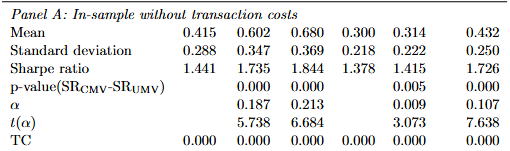

In [171]:
def print_summary1(results):
    performance_metrics = results['PerformanceMetrics']
    n_rows = performance_metrics.shape[0]
    strategy_names = ['UMV', 'CFW', 'CMV', 'UMV-TC', 'CFW-TC', 'CMV-TC']
    panel_descriptions = ['In-Sample without Transaction Costs','Out-of-Sample without Transaction Costs','Out-of-Sample with TC (no trading div.)',
        'Out-of-Sample with TC (with trading div.)']
    print(" " + " ".join(f"{name:>8}" for name in strategy_names[:min(6, performance_metrics.shape[1])]))
    
    for panel_idx in range(4):
        start_row = panel_idx * 7
        end_row = min((panel_idx + 1) * 7, n_rows)
        
        print(f"\nPanel {chr(65 + panel_idx)}: {panel_descriptions[panel_idx]}")
        for i in range(start_row, end_row):
            row_str = "   "
            for j in range(min(6, performance_metrics.shape[1])):
                if not np.isnan(performance_metrics[i, j]):
                    row_str += f"{performance_metrics[i, j]:8.3f}"
                else:
                    row_str += "        "
            print(row_str)

In [172]:
print_summary1(results)

      UMV      CFW      CMV   UMV-TC   CFW-TC   CMV-TC

Panel A: In-Sample without Transaction Costs
      0.422   0.605   0.686   0.301   0.355   0.432
      0.293   0.348   0.372   0.218   0.232   0.250
      1.441   1.740   1.845   1.379   1.531   1.728
              0.000   0.000           0.000   0.000
              0.190   0.214           0.043   0.107
              5.730   6.574           5.400   7.640
      0.000   0.000   0.000   0.000   0.000   0.000

Panel B: Out-of-Sample without Transaction Costs
      0.764   0.787   0.924   0.593   0.599   0.690
      0.583   0.526   0.577   0.457   0.443   0.449
      1.311   1.497   1.600   1.296   1.351   1.538
              0.005   0.000           0.000   0.000
              0.139   0.210           0.026   0.126
              4.752   5.267           4.949   6.419
      0.000   0.000   0.000   0.000   0.000   0.000

Panel C: Out-of-Sample with TC (no trading div.)
      0.414   0.309   0.348   0.347   0.317   0.332
      0.583   0.526

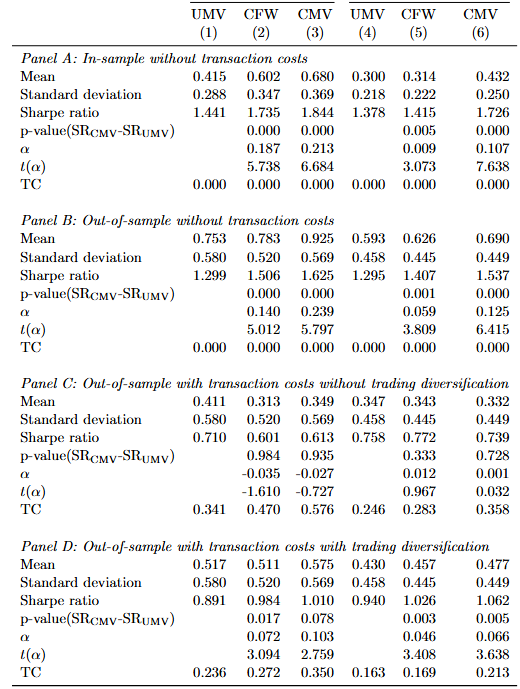